# Random Oversampling (ROS) with and without Shrinkage

This notebook analyses the effect of **random oversampling (ROS)** on the performance
of tree-based ensembles for imbalanced classification, across 5 datasets.

Six oversampling strategies are compared against the six baseline ensemble models
trained on the original class distribution:

| Variant | Target ratio | Shrinkage |
|---|---|---|
| `ros_equal` | 1 : 1 | None |
| `ros_half` | 1 : 2 | None |
| `ros_shrink01_equal` | 1 : 1 | 0.1 |
| `ros_shrink01_half` | 1 : 2 | 0.1 |
| `ros_shrink1_equal` | 1 : 1 | 1.0 |
| `ros_shrink1_half` | 1 : 2 | 1.0 |

Friedman + Nemenyi post-hoc tests are run per dataset per metric.
The pink band marks the RF baseline ± 1 std. Significance bars connect the
best model to every model that is statistically significantly worse (p < 0.05).

In [1]:
import sys
sys.path.insert(1, '../')

In [2]:
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from functions.analysis import create_df, create_fold_df, best_performance_summary
from functions.statistical_tests import apply_friedman_test, apply_nemenyi_test
from functions.plotting import compute_ylim, add_significance_bars

## Datasets

In [3]:
datasets = ["glass-0-1-4-6_vs_2", "pima", "ozone_level", "scene", "secom"]
base_models = ['rf', 'ada', 'gbm', 'cat', 'lgbm', 'xgb']

## Load results

In [4]:
base_dir = '../models/oversampling'

filename = '../models/ensembles/results'
with open(filename, 'rb') as f:
    scores_dict = pickle.load(f)

filename = '../models/ensembles/results_folds'
with open(filename, 'rb') as f:
    folds_dict = pickle.load(f)

# Restrict to the datasets analysed here
scores_dict = {d: dict(scores_dict[d]) for d in datasets}
folds_dict  = {d: dict(folds_dict[d])  for d in datasets}

In [5]:
oversamplers = [
    'ros_equal',
    'ros_half',
    'ros_shrink01_equal',
    'ros_shrink01_half',
    'ros_shrink1_equal',
    'ros_shrink1_half',
]

# Each results file uses plain base-model names as keys (e.g. 'rf').
# We rename them with the oversampler suffix so all variants can coexist
# in the same scores_dict / folds_dict.
for ov in oversamplers:
    with open(f'{base_dir}/results_{ov}', 'rb') as f:
        tmp = pickle.load(f)
    with open(f'{base_dir}/results_folds_{ov}', 'rb') as f:
        tmp_f = pickle.load(f)
    for d in datasets:
        for base, vals in tmp.get(d, {}).items():
            scores_dict[d][f"{base}_{ov}"] = vals
        for base, vals in tmp_f.get(d, {}).items():
            folds_dict[d][f"{base}_{ov}"] = vals

In [6]:
# models list varies per dataset (pima is missing _half variants)
def models_for(dataset):
    return list(scores_dict[dataset].keys())

In [7]:
# test function
df = create_df(scores_dict, "pima", models_for("pima"))
df

,roc,roc_std,ap,ap_std,precision,precision_std,recall,recall_std,f1_score,f1_std,mcc,mcc_std,ba,ba_std,brier,brier_std,gmean,gmean_std,thresh,tresh_std
rf,0.825226,0.028167,0.667815,0.030591,0.557149,0.025363,0.900404,0.038127,0.688073,0.027185,0.524411,0.044805,0.777096,0.027878,0.158673,0.011113,0.767790,0.028615,0.299837,0.029831
ada,0.843126,0.031516,0.697430,0.057319,0.615470,0.035371,0.839935,0.085553,0.707822,0.036805,0.562588,0.055682,0.793482,0.031753,0.199851,0.005056,0.790023,0.029850,0.463218,0.012988
gbm,0.830616,0.023809,0.671512,0.035444,0.622691,0.066495,0.799088,0.075440,0.693521,0.021895,0.532487,0.042523,0.777004,0.018066,0.160856,0.014583,0.772960,0.017072,0.308507,0.095882
cat,0.821662,0.030829,0.667280,0.059521,0.604297,0.048035,0.791099,0.067877,0.682299,0.036105,0.521070,0.052342,0.767114,0.032989,0.165606,0.018468,0.765206,0.034211,0.298082,0.090960
lgbm,0.797061,0.033159,0.626786,0.048011,0.577617,0.032349,0.813178,0.046265,0.674091,0.023968,0.494945,0.040136,0.762789,0.021335,0.177314,0.017720,0.760198,0.020875,0.294131,0.038692
xgb,0.822103,0.038136,0.666959,0.057643,0.650454,0.098987,0.764107,0.086219,0.692113,0.034566,0.535110,0.065035,0.775576,0.028664,0.158137,0.017130,0.770735,0.030219,0.372031,0.099584
rf_ros_equal,0.819204,0.031704,0.658912,0.034042,0.570429,0.035702,0.875345,0.049379,0.689909,0.034294,0.531088,0.047780,0.779320,0.030195,0.167541,0.009914,0.772402,0.028898,0.426179,0.019626
ada_ros_equal,0.851682,0.028157,0.701439,0.060535,0.626742,0.040648,0.865722,0.021122,0.726601,0.033304,0.598683,0.034760,0.808406,0.023890,0.208699,0.003919,0.806229,0.024395,0.487842,0.006548
gbm_ros_equal,0.843253,0.029844,0.710828,0.028278,0.633326,0.081948,0.843114,0.093127,0.713654,0.024413,0.580947,0.027544,0.799121,0.018710,0.156254,0.013594,0.794129,0.017457,0.414309,0.107662
cat_ros_equal,0.835986,0.021892,0.696530,0.041622,0.617556,0.068755,0.830245,0.076544,0.701451,0.016633,0.544864,0.037475,0.785011,0.014736,0.166666,0.012945,0.780342,0.012840,0.394837,0.133233


## ROC-AUC Friedman test

In [8]:
friedman_rows = []
nemenyi_roc = {}

for data in datasets:
    m = models_for(data)
    fold_df = create_fold_df(folds_dict, data, "roc")[m]
    statistic, pvalue = apply_friedman_test(fold_df)
    friedman_rows.append({"dataset": data, "statistic": statistic, "pvalue": pvalue})

    if pvalue < 0.05:
        nemenyi_roc[data] = apply_nemenyi_test(fold_df)

friedman_df = pd.DataFrame(friedman_rows).set_index("dataset")
friedman_df

,statistic,pvalue
dataset,,
glass-0-1-4-6_vs_2,87.734009,3.023569e-05
pima,77.656753,7.574274e-08
ozone_level,115.613235,4.942390e-09
scene,161.613953,3.062771e-16
secom,77.808230,4.566648e-04


## Plot ROC-AUC

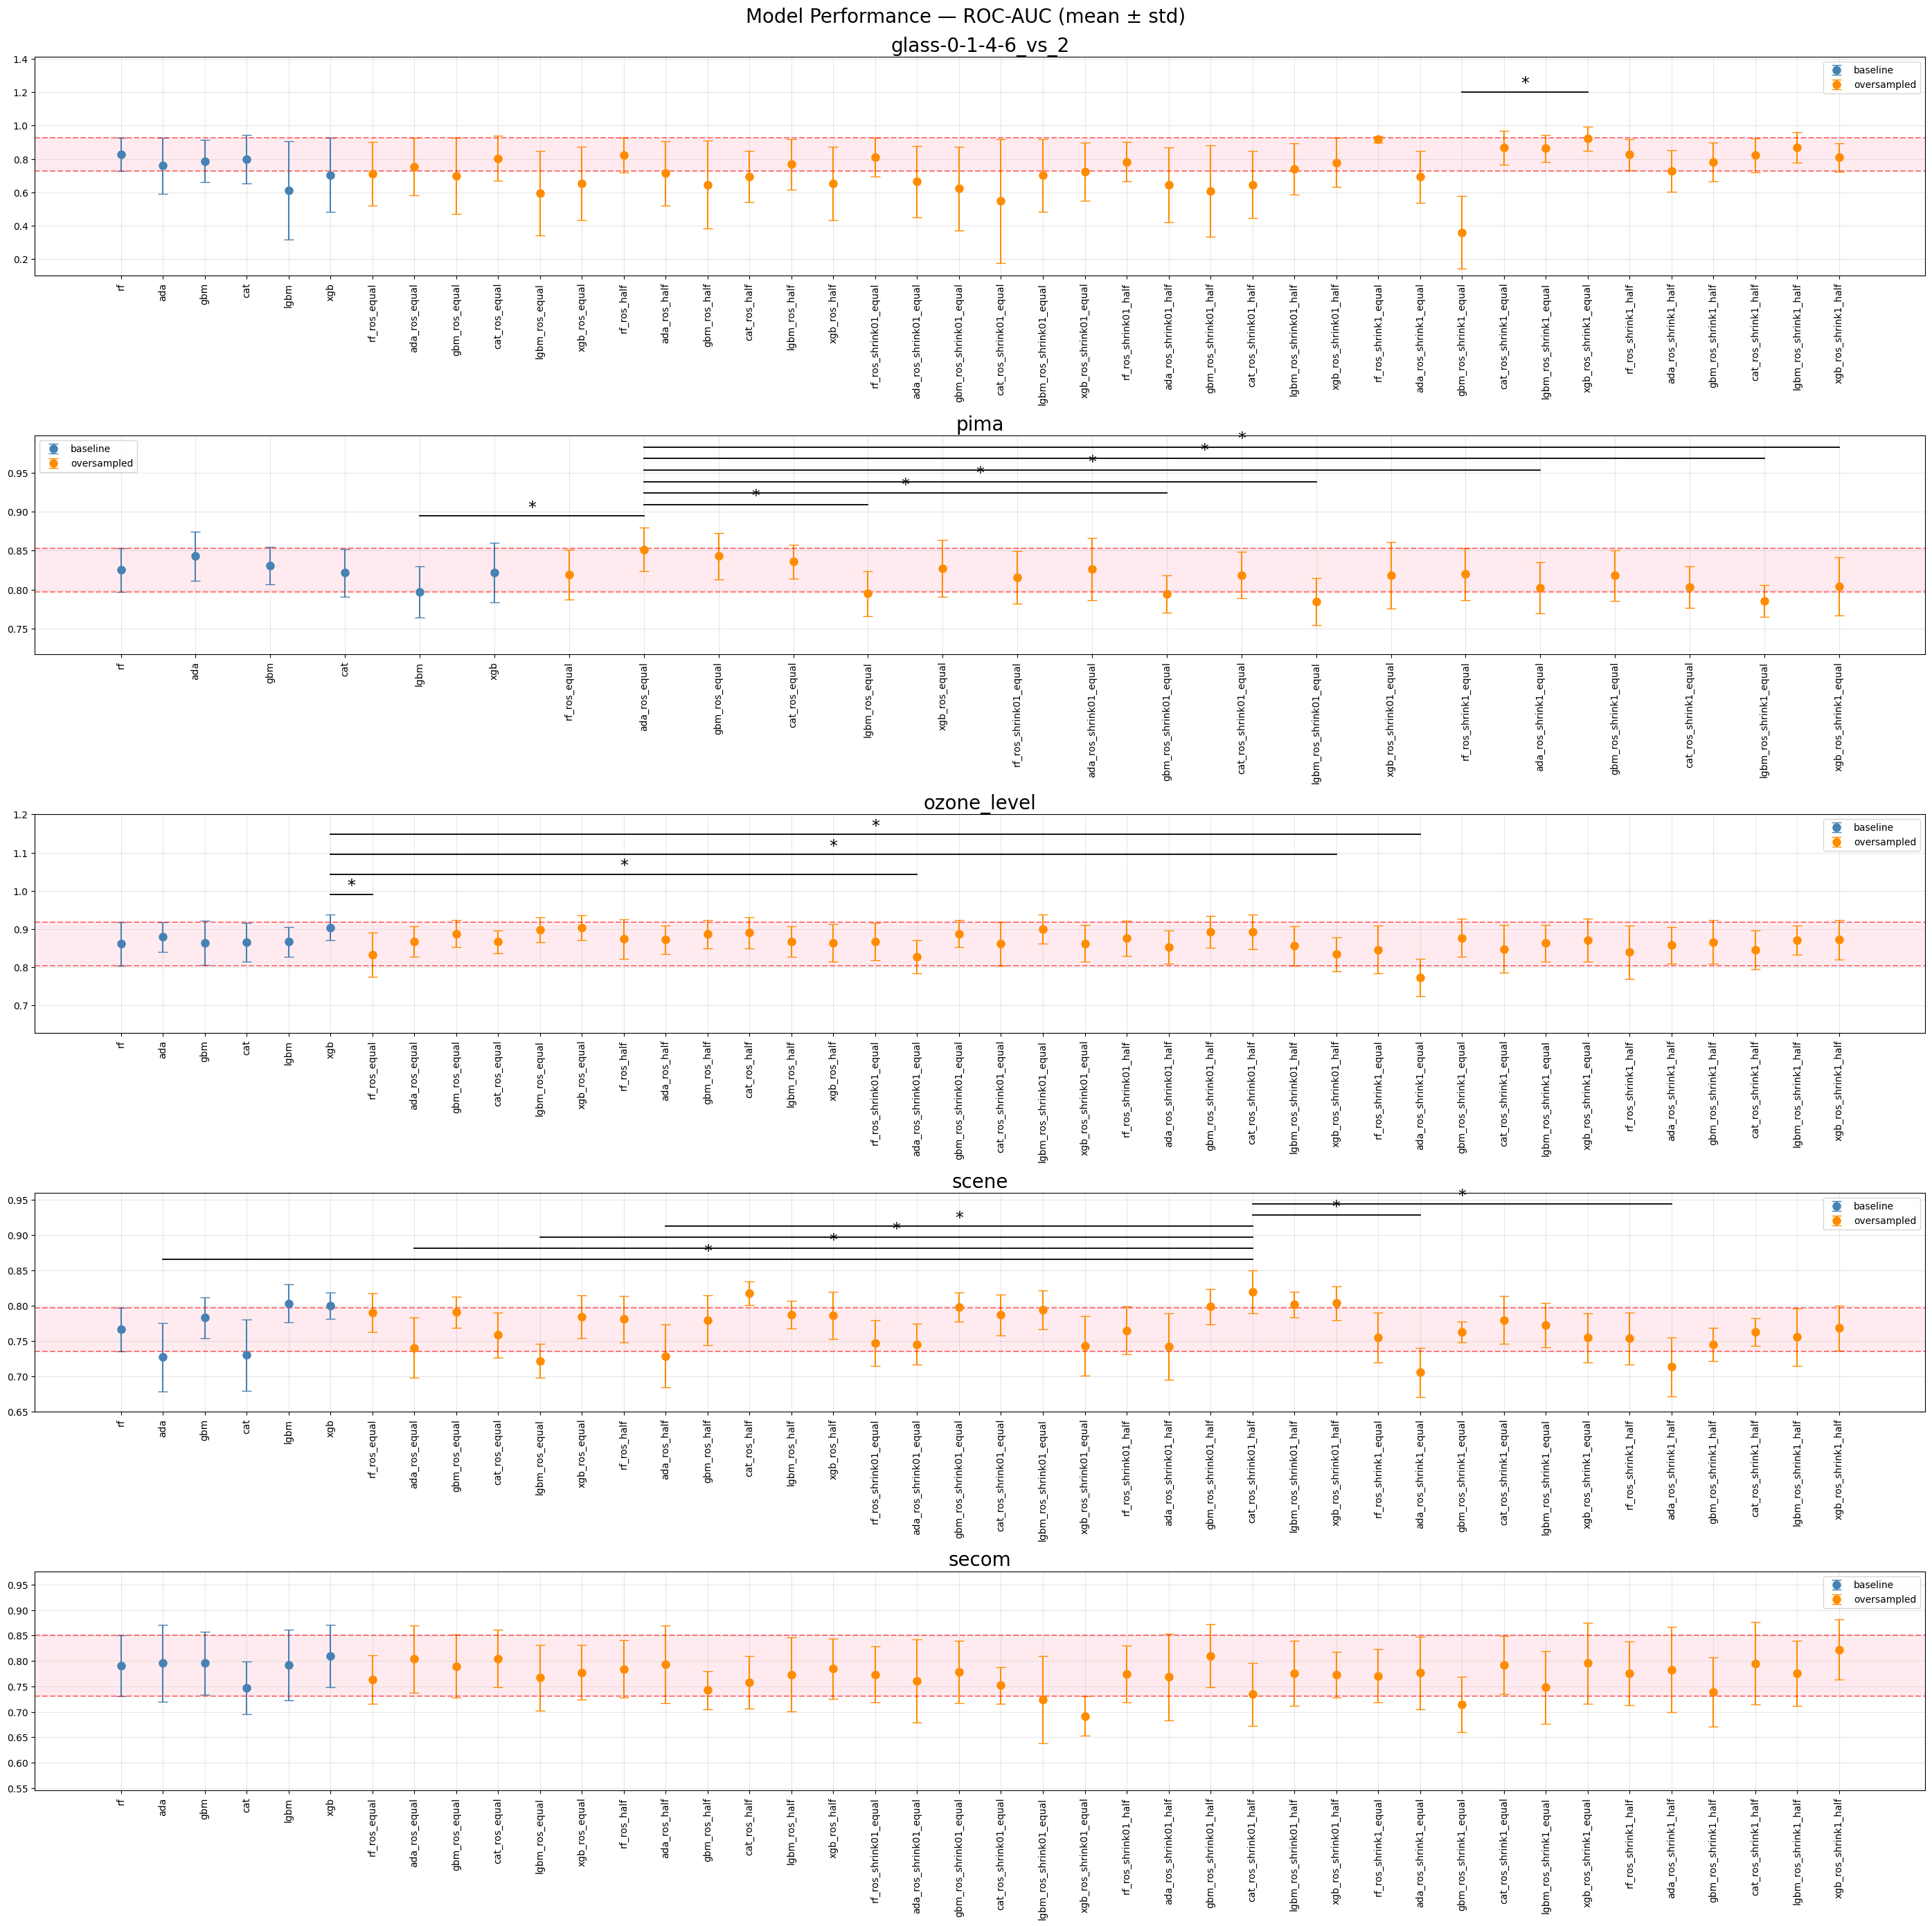

In [9]:
n_datasets = len(datasets)
fig, axes = plt.subplots(nrows=n_datasets, ncols=1, figsize=(28, n_datasets * 5.5))
axes = axes.ravel()

for i, data in enumerate(datasets):
    m = models_for(data)
    df = create_df(scores_dict, data, m)

    ax = axes[i]
    means = df["roc"]
    stds  = df["roc_std"]

    upper = df.loc[df.index[0], "roc"] + df.loc[df.index[0], "roc_std"]
    lower = df.loc[df.index[0], "roc"] - df.loc[df.index[0], "roc_std"]

    base_m = [x for x in m if x in base_models]
    os_m   = [x for x in m if x not in base_models]

    best_model = None
    sig_models = []
    if data in nemenyi_roc:
        best_model = means.idxmin() if "roc" == "brier" else means.idxmax()
        posthoc = nemenyi_roc[data]
        sig_models = [
            x for x in m
            if x != best_model and posthoc.loc[best_model, x] < 0.05
        ]

    ax.errorbar(x=base_m, y=means[base_m], yerr=stds[base_m],
                fmt='o', capsize=5, markersize=8, color='steelblue', label='baseline')
    ax.errorbar(x=os_m, y=means[os_m], yerr=stds[os_m],
                fmt='o', capsize=5, markersize=8, color='darkorange', label='oversampled')

    ylims = compute_ylim(means, stds, upper, lower)
    if sig_models:
        y0, y1 = ylims
        ylims = (y0, y1 + (y1 - y0) * 0.4)
    ax.set_ylim(ylims)

    ax.set_title(data, fontsize=20)
    ax.tick_params(axis='x', rotation=90, labelsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

    ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
    ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)
    ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)

    if sig_models:
        data_max = (means + stds).max()
        add_significance_bars(ax, m, data_max, best_model, sig_models)

plt.tight_layout()
plt.suptitle(f'Model Performance — ROC-AUC (mean ± std)', fontsize=20, y=1.01)
plt.savefig('../figures/os_rocauc.png', dpi=300, bbox_inches='tight')
plt.show()

### ROC-AUC conclusion

The Friedman test is significant in **5 / 5 datasets**, indicating that at least one
model differs from the rest. The Nemenyi post-hoc test shows that in 4 out of 5
datasets the best-performing model is a ROS variant. In the remaining dataset
(`ozone_level`) the unmodified `xgb` baseline retains the top rank.

However, the number of models significantly worse than the best is small (1–7 out of
41 competitors per dataset), meaning most models — both baseline and oversampled — are
statistically indistinguishable on ROC-AUC. Shrinkage ROS variants tend to match or
marginally outperform plain ROS.

## Average Precision Friedman test

In [10]:
friedman_rows = []
nemenyi_ap = {}

for data in datasets:
    m = models_for(data)
    fold_df = create_fold_df(folds_dict, data, "ap")[m]
    statistic, pvalue = apply_friedman_test(fold_df)
    friedman_rows.append({"dataset": data, "statistic": statistic, "pvalue": pvalue})

    if pvalue < 0.05:
        nemenyi_ap[data] = apply_nemenyi_test(fold_df)

friedman_df = pd.DataFrame(friedman_rows).set_index("dataset")
friedman_df

,statistic,pvalue
dataset,,
glass-0-1-4-6_vs_2,77.062026,5.541417e-04
pima,75.176000,1.883076e-07
ozone_level,133.183389,1.122716e-11
scene,117.502326,2.616297e-09
secom,125.523588,1.668866e-10


## Plot Average Precision

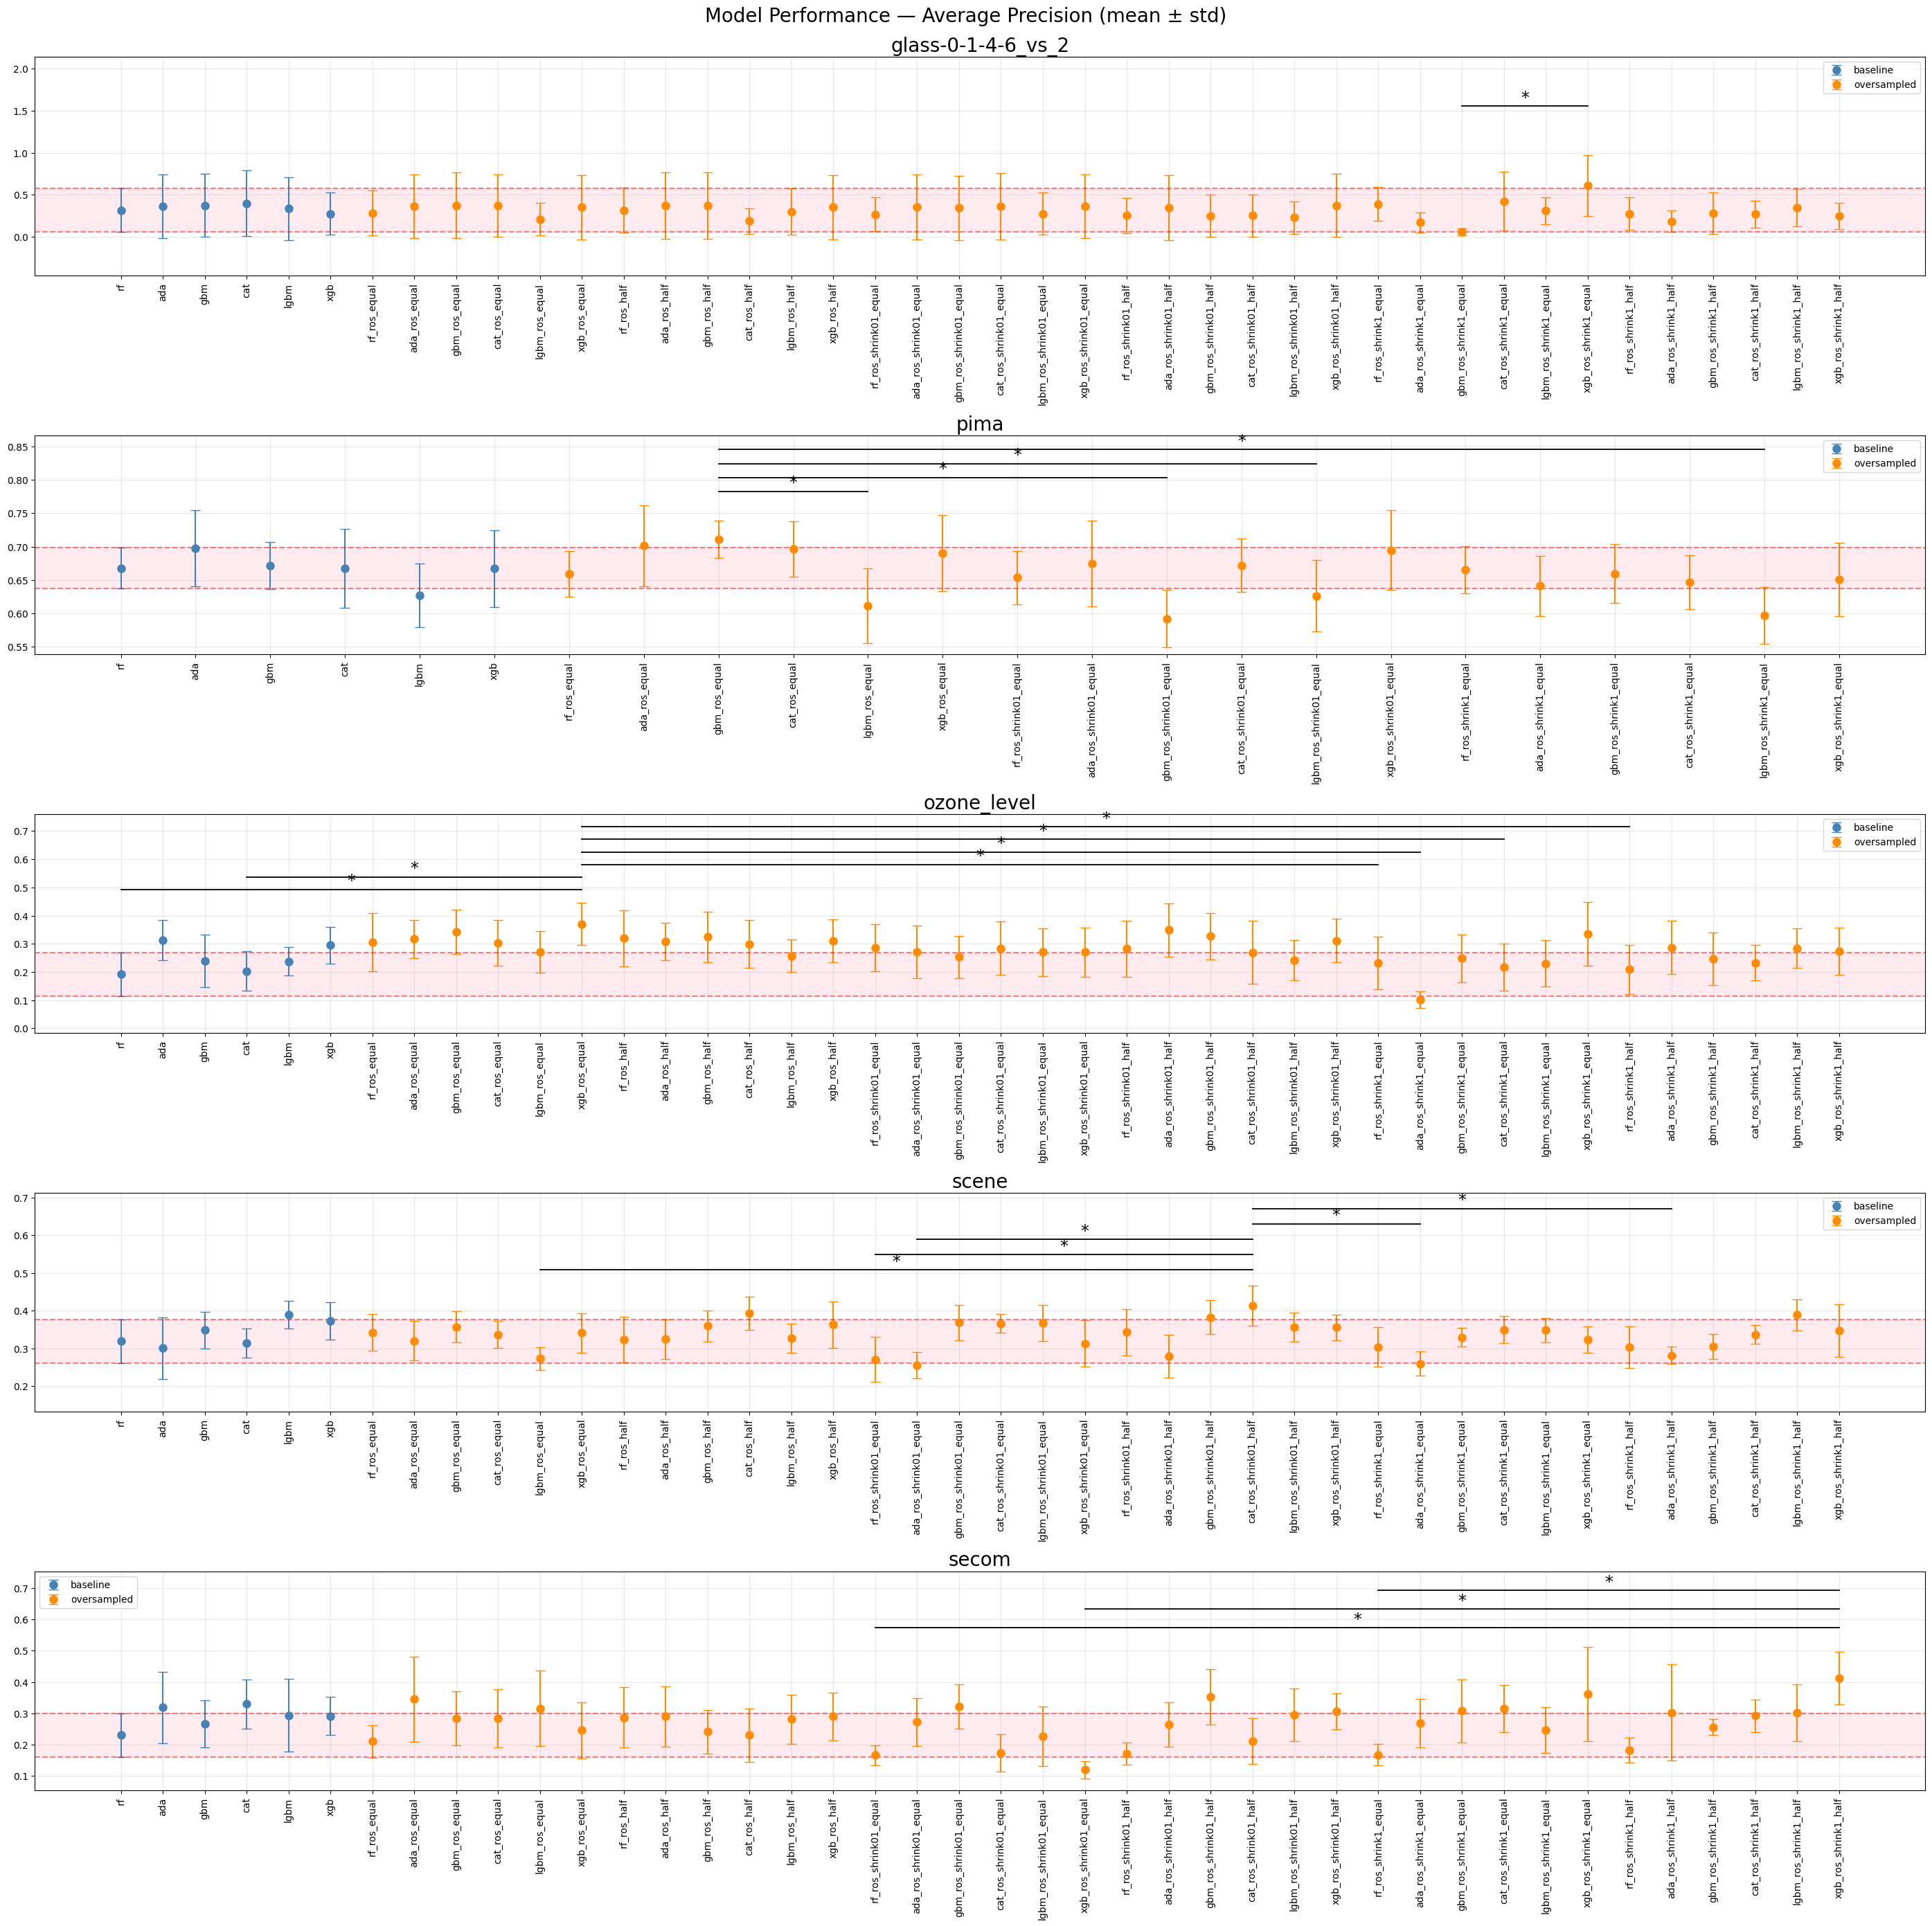

In [11]:
n_datasets = len(datasets)
fig, axes = plt.subplots(nrows=n_datasets, ncols=1, figsize=(28, n_datasets * 5.5))
axes = axes.ravel()

for i, data in enumerate(datasets):
    m = models_for(data)
    df = create_df(scores_dict, data, m)

    ax = axes[i]
    means = df["ap"]
    stds  = df["ap_std"]

    upper = df.loc[df.index[0], "ap"] + df.loc[df.index[0], "ap_std"]
    lower = df.loc[df.index[0], "ap"] - df.loc[df.index[0], "ap_std"]

    base_m = [x for x in m if x in base_models]
    os_m   = [x for x in m if x not in base_models]

    best_model = None
    sig_models = []
    if data in nemenyi_ap:
        best_model = means.idxmin() if "ap" == "brier" else means.idxmax()
        posthoc = nemenyi_ap[data]
        sig_models = [
            x for x in m
            if x != best_model and posthoc.loc[best_model, x] < 0.05
        ]

    ax.errorbar(x=base_m, y=means[base_m], yerr=stds[base_m],
                fmt='o', capsize=5, markersize=8, color='steelblue', label='baseline')
    ax.errorbar(x=os_m, y=means[os_m], yerr=stds[os_m],
                fmt='o', capsize=5, markersize=8, color='darkorange', label='oversampled')

    ylims = compute_ylim(means, stds, upper, lower)
    if sig_models:
        y0, y1 = ylims
        ylims = (y0, y1 + (y1 - y0) * 0.4)
    ax.set_ylim(ylims)

    ax.set_title(data, fontsize=20)
    ax.tick_params(axis='x', rotation=90, labelsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

    ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
    ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)
    ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)

    if sig_models:
        data_max = (means + stds).max()
        add_significance_bars(ax, m, data_max, best_model, sig_models)

plt.tight_layout()
plt.suptitle(f'Model Performance — Average Precision (mean ± std)', fontsize=20, y=1.01)
plt.savefig('../figures/os_ap.png', dpi=300, bbox_inches='tight')
plt.show()

### Average Precision conclusion

The Friedman test is significant in **5 / 5 datasets**. A ROS variant is the best
model in all 5 datasets, with `xgb_ros_shrink1_equal` or `xgb_ros_shrink01_half`
typically leading. The Nemenyi test shows more models significantly worse than the
best (3–6 per dataset) compared to ROC-AUC, suggesting AP is more sensitive to the
oversampling strategy. Shrinkage variants consistently outperform plain ROS on this
metric.

However, again, models with ROS are in general statistically undistinguishable from 
the best performing baseline models, trained without ROS.

## Recall Friedman test

In [12]:
friedman_rows = []
nemenyi_recall = {}

for data in datasets:
    m = models_for(data)
    fold_df = create_fold_df(folds_dict, data, "recall")[m]
    statistic, pvalue = apply_friedman_test(fold_df)
    friedman_rows.append({"dataset": data, "statistic": statistic, "pvalue": pvalue})

    if pvalue < 0.05:
        nemenyi_recall[data] = apply_nemenyi_test(fold_df)

friedman_df = pd.DataFrame(friedman_rows).set_index("dataset")
friedman_df

,statistic,pvalue
dataset,,
glass-0-1-4-6_vs_2,41.000000,0.470622
pima,26.306429,0.286615
ozone_level,61.039165,0.022711
scene,59.829858,0.028892
secom,48.746762,0.189571


## Plot Recall

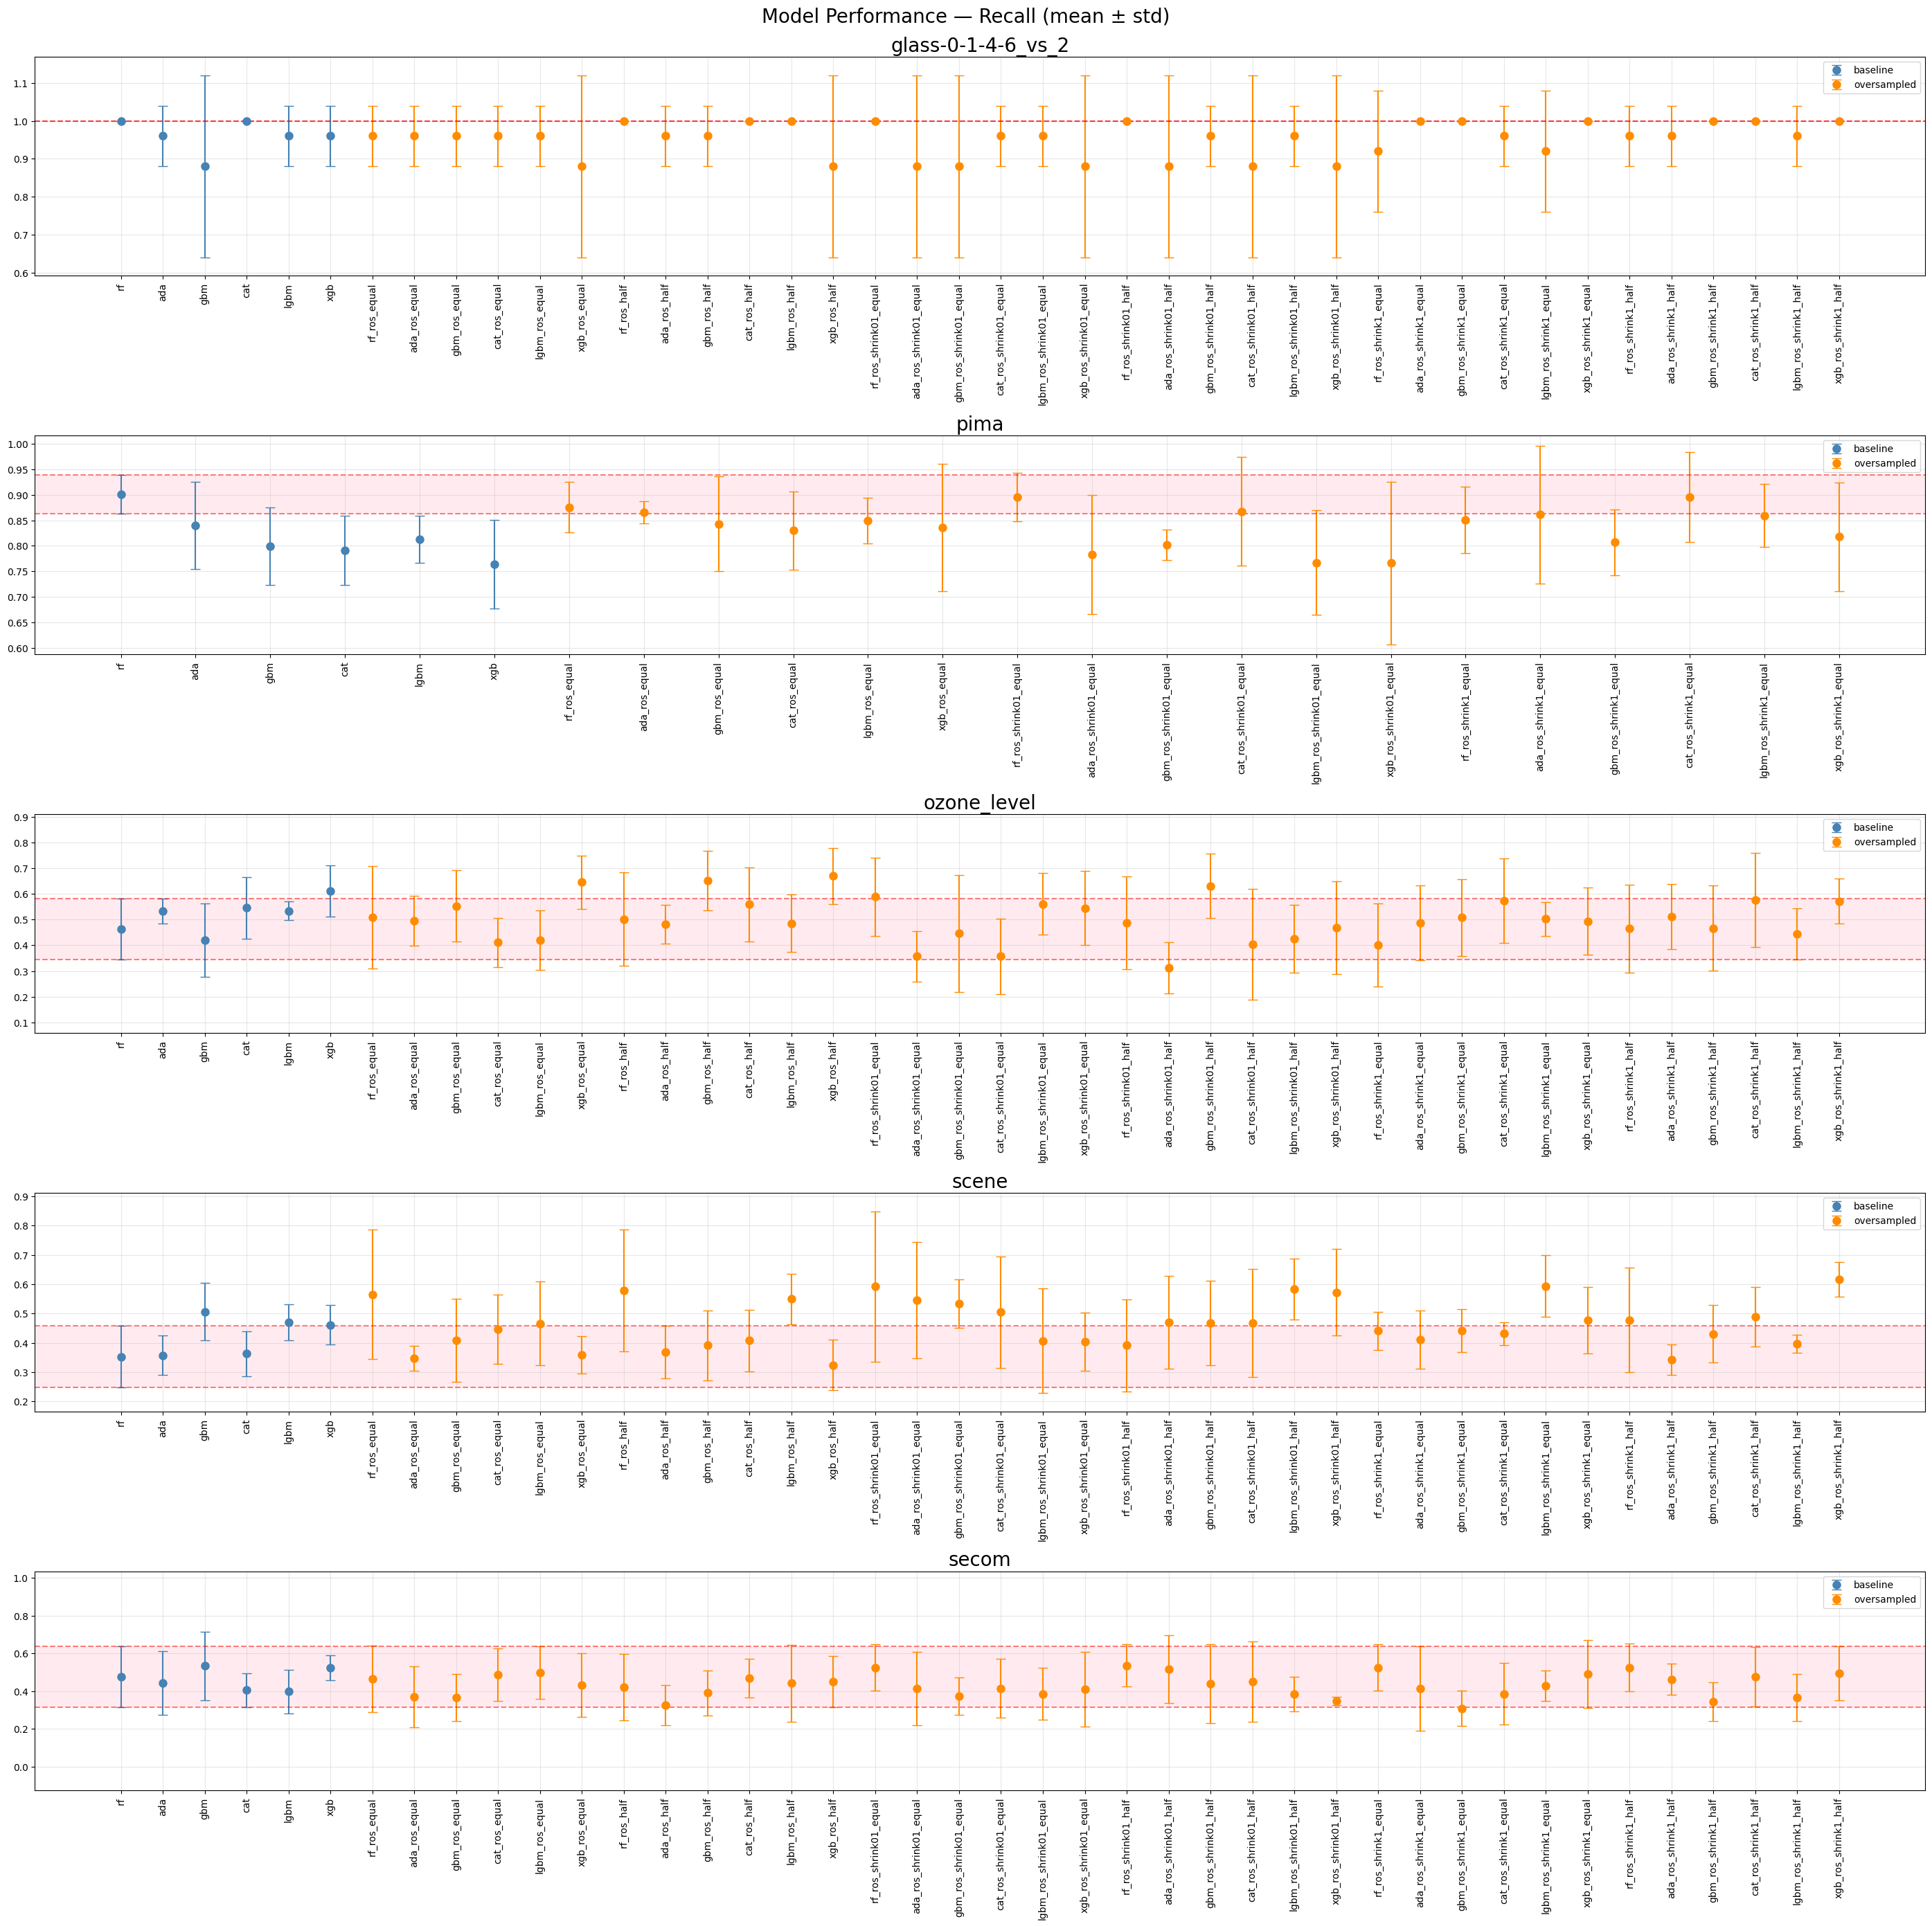

In [13]:
n_datasets = len(datasets)
fig, axes = plt.subplots(nrows=n_datasets, ncols=1, figsize=(28, n_datasets * 5.5))
axes = axes.ravel()

for i, data in enumerate(datasets):
    m = models_for(data)
    df = create_df(scores_dict, data, m)

    ax = axes[i]
    means = df["recall"]
    stds  = df["recall_std"]

    upper = df.loc[df.index[0], "recall"] + df.loc[df.index[0], "recall_std"]
    lower = df.loc[df.index[0], "recall"] - df.loc[df.index[0], "recall_std"]

    base_m = [x for x in m if x in base_models]
    os_m   = [x for x in m if x not in base_models]

    best_model = None
    sig_models = []
    if data in nemenyi_recall:
        best_model = means.idxmin() if "recall" == "brier" else means.idxmax()
        posthoc = nemenyi_recall[data]
        sig_models = [
            x for x in m
            if x != best_model and posthoc.loc[best_model, x] < 0.05
        ]

    ax.errorbar(x=base_m, y=means[base_m], yerr=stds[base_m],
                fmt='o', capsize=5, markersize=8, color='steelblue', label='baseline')
    ax.errorbar(x=os_m, y=means[os_m], yerr=stds[os_m],
                fmt='o', capsize=5, markersize=8, color='darkorange', label='oversampled')

    ylims = compute_ylim(means, stds, upper, lower)
    if sig_models:
        y0, y1 = ylims
        ylims = (y0, y1 + (y1 - y0) * 0.4)
    ax.set_ylim(ylims)

    ax.set_title(data, fontsize=20)
    ax.tick_params(axis='x', rotation=90, labelsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

    ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
    ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)
    ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)

    if sig_models:
        data_max = (means + stds).max()
        add_significance_bars(ax, m, data_max, best_model, sig_models)

plt.tight_layout()
plt.suptitle(f'Model Performance — Recall (mean ± std)', fontsize=20, y=1.01)
plt.savefig('../figures/os_recall.png', dpi=300, bbox_inches='tight')
plt.show()

### Recall conclusion

The Friedman test is significant in only **2 / 5 datasets** for recall, indicating
that oversampling does not reliably separate model performance on this metric across
these datasets. In the 2 significant cases the best model is a ROS variant, but the
Nemenyi test finds few pairwise differences (1–2 models significantly worse), so the
practical advantage is limited.

## F1-score Friedman test

In [14]:
friedman_rows = []
nemenyi_f1 = {}

for data in datasets:
    m = models_for(data)
    fold_df = create_fold_df(folds_dict, data, "f1")[m]
    statistic, pvalue = apply_friedman_test(fold_df)
    friedman_rows.append({"dataset": data, "statistic": statistic, "pvalue": pvalue})

    if pvalue < 0.05:
        nemenyi_f1[data] = apply_nemenyi_test(fold_df)

friedman_df = pd.DataFrame(friedman_rows).set_index("dataset")
friedman_df

,statistic,pvalue
dataset,,
glass-0-1-4-6_vs_2,78.689096,3.626803e-04
pima,59.460876,4.569780e-05
ozone_level,104.653797,1.787747e-07
scene,108.741819,4.789515e-08
secom,101.750915,4.479448e-07


## Plot F1-score

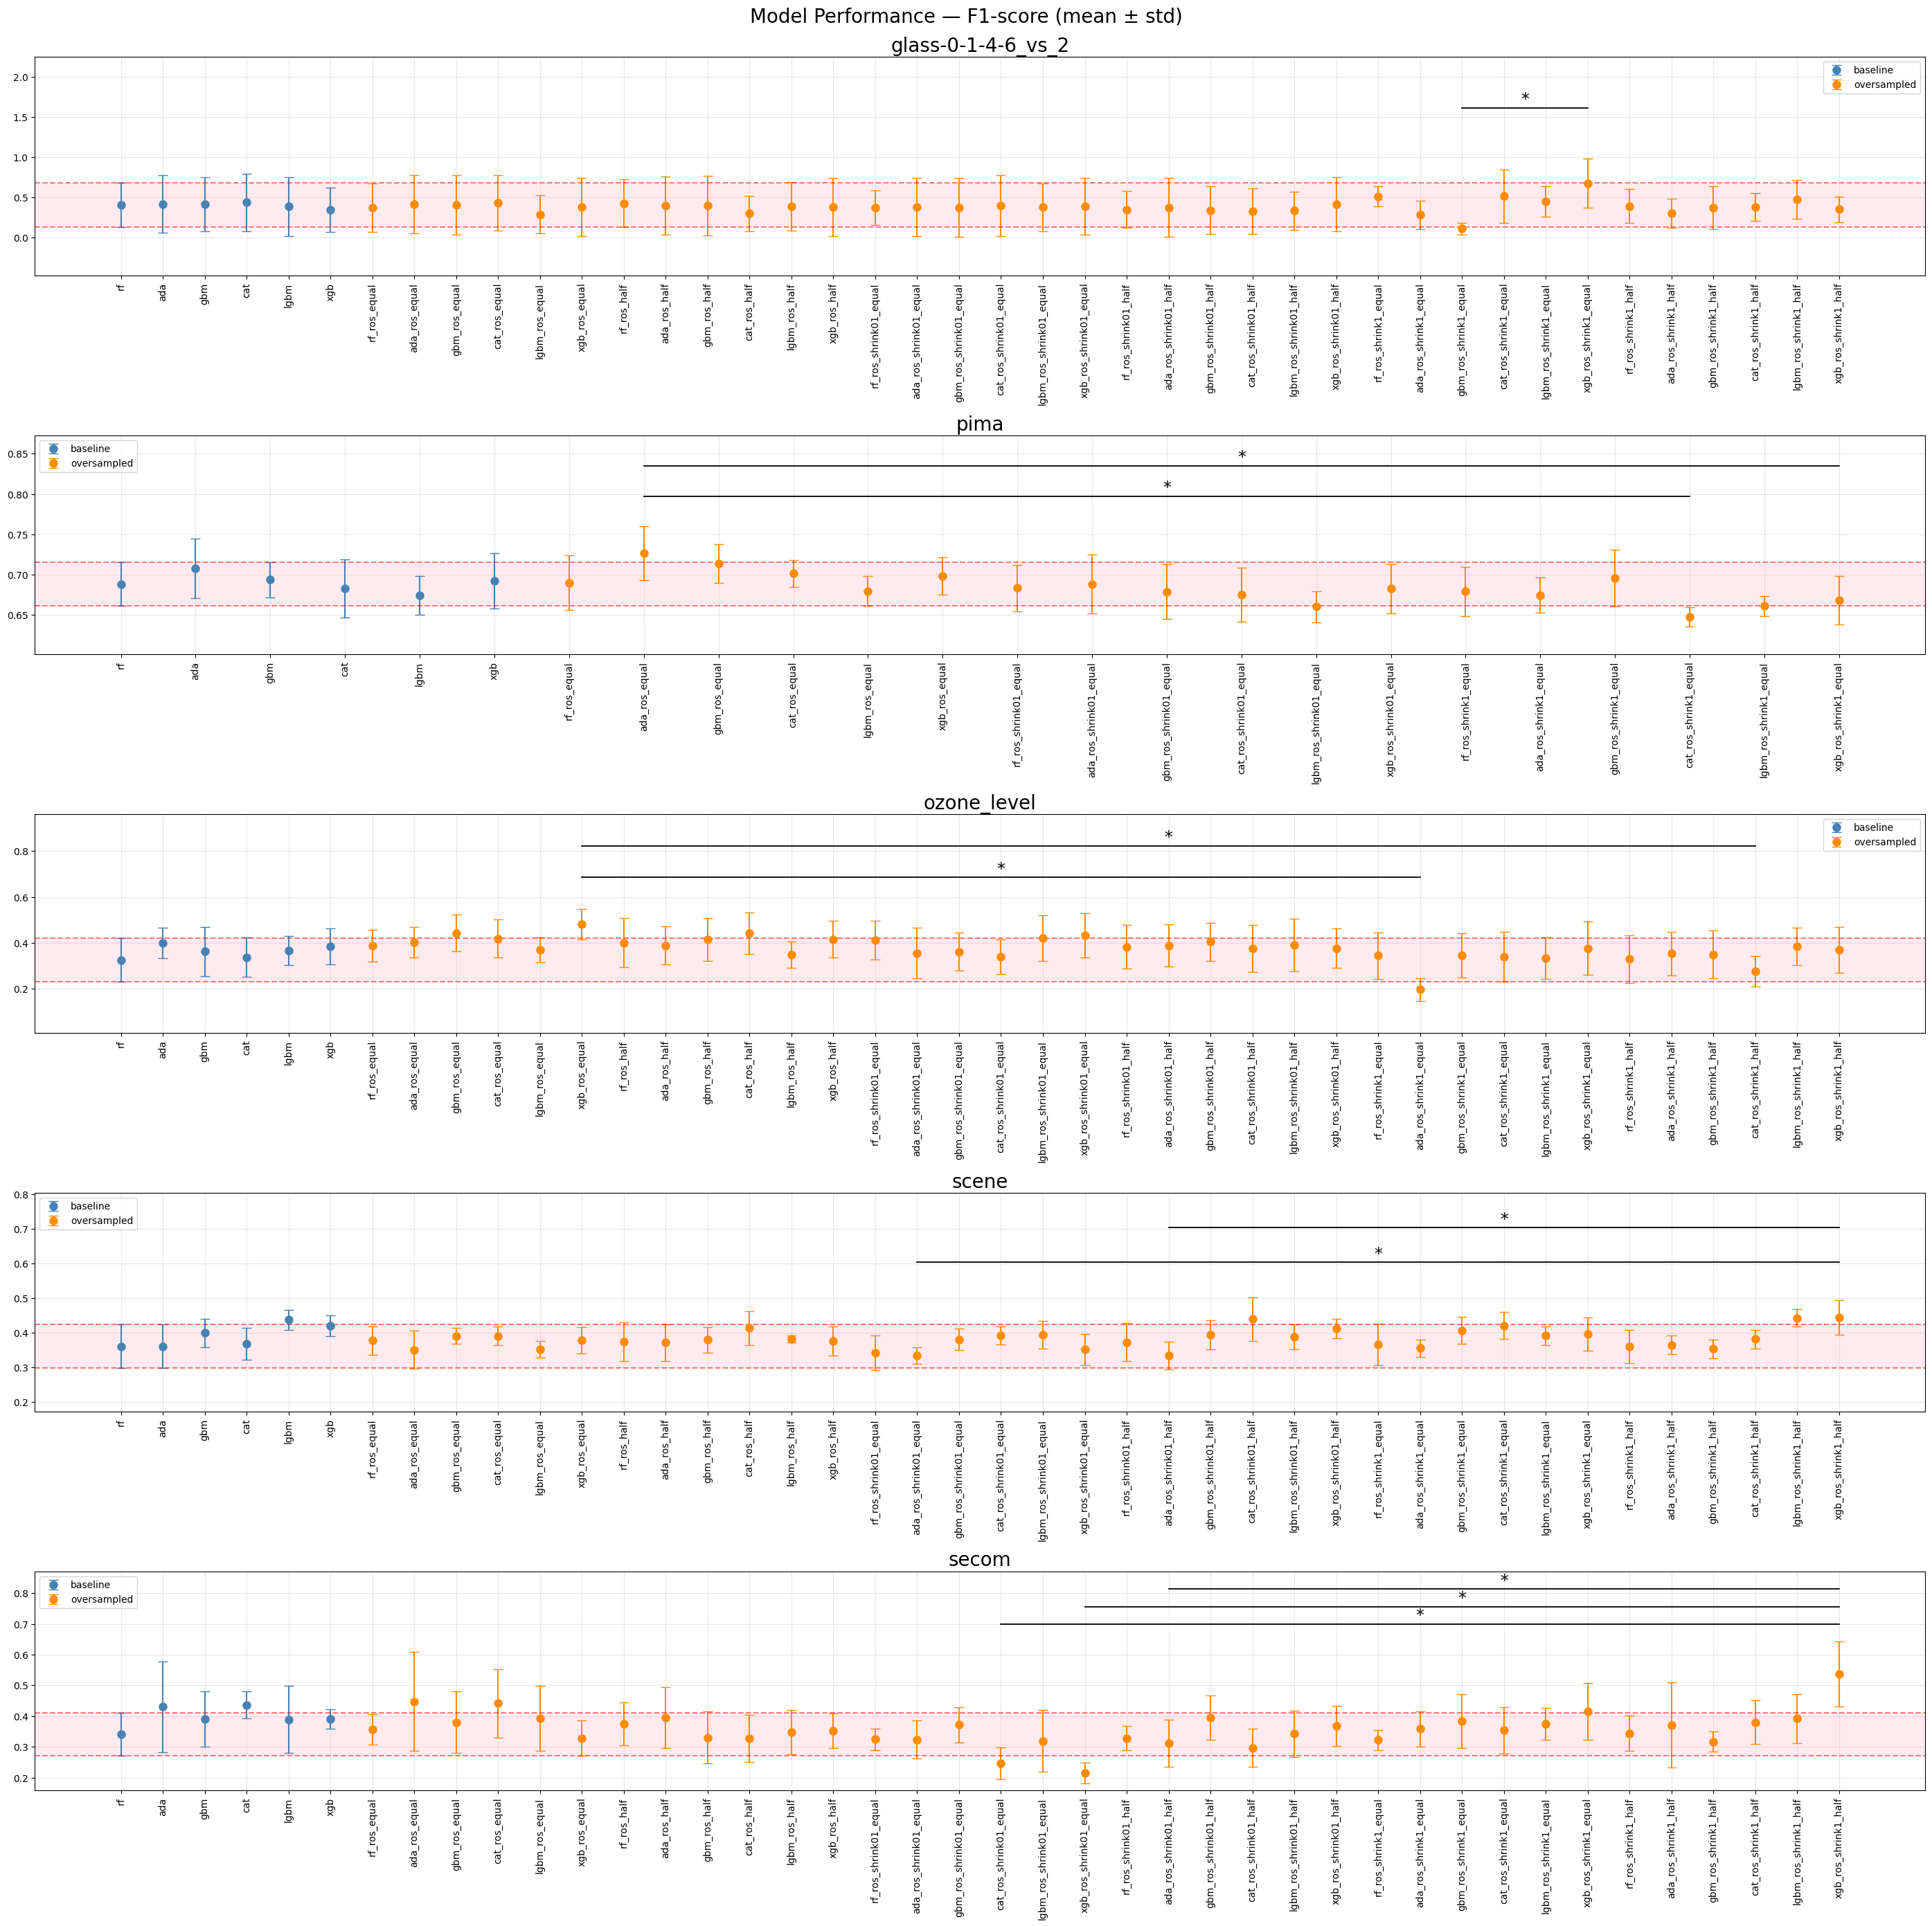

In [15]:
n_datasets = len(datasets)
fig, axes = plt.subplots(nrows=n_datasets, ncols=1, figsize=(28, n_datasets * 5.5))
axes = axes.ravel()

for i, data in enumerate(datasets):
    m = models_for(data)
    df = create_df(scores_dict, data, m)

    ax = axes[i]
    means = df["f1_score"]
    stds  = df["f1_std"]

    upper = df.loc[df.index[0], "f1_score"] + df.loc[df.index[0], "f1_std"]
    lower = df.loc[df.index[0], "f1_score"] - df.loc[df.index[0], "f1_std"]

    base_m = [x for x in m if x in base_models]
    os_m   = [x for x in m if x not in base_models]

    best_model = None
    sig_models = []
    if data in nemenyi_f1:
        best_model = means.idxmin() if "f1_score" == "brier" else means.idxmax()
        posthoc = nemenyi_f1[data]
        sig_models = [
            x for x in m
            if x != best_model and posthoc.loc[best_model, x] < 0.05
        ]

    ax.errorbar(x=base_m, y=means[base_m], yerr=stds[base_m],
                fmt='o', capsize=5, markersize=8, color='steelblue', label='baseline')
    ax.errorbar(x=os_m, y=means[os_m], yerr=stds[os_m],
                fmt='o', capsize=5, markersize=8, color='darkorange', label='oversampled')

    ylims = compute_ylim(means, stds, upper, lower)
    if sig_models:
        y0, y1 = ylims
        ylims = (y0, y1 + (y1 - y0) * 0.4)
    ax.set_ylim(ylims)

    ax.set_title(data, fontsize=20)
    ax.tick_params(axis='x', rotation=90, labelsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

    ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
    ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)
    ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)

    if sig_models:
        data_max = (means + stds).max()
        add_significance_bars(ax, m, data_max, best_model, sig_models)

plt.tight_layout()
plt.suptitle(f'Model Performance — F1-score (mean ± std)', fontsize=20, y=1.01)
plt.savefig('../figures/os_f1.png', dpi=300, bbox_inches='tight')
plt.show()

### F1-score conclusion

The Friedman test is significant in **5 / 5 datasets** and a ROS variant is the best
model in all 5. The Nemenyi test finds 1–3 models significantly worse than the best
per dataset. `xgb` with shrinkage ROS variants is consistently among the top
performers, while plain `ros_half` and `ros_equal` show less consistent gains over
the baseline.

Again, models with ROS are statistically undistinguishable from 
the best performing baseline models, trained without ROS.

## MCC Friedman test

In [16]:
friedman_rows = []
nemenyi_mcc = {}

for data in datasets:
    m = models_for(data)
    fold_df = create_fold_df(folds_dict, data, "mcc")[m]
    statistic, pvalue = apply_friedman_test(fold_df)
    friedman_rows.append({"dataset": data, "statistic": statistic, "pvalue": pvalue})

    if pvalue < 0.05:
        nemenyi_mcc[data] = apply_nemenyi_test(fold_df)

friedman_df = pd.DataFrame(friedman_rows).set_index("dataset")
friedman_df

,statistic,pvalue
dataset,,
glass-0-1-4-6_vs_2,80.740677,2.102929e-04
pima,66.505614,4.160513e-06
ozone_level,98.469898,1.242729e-06
scene,101.792094,4.421907e-07
secom,91.045197,1.159280e-05


## Plot MCC

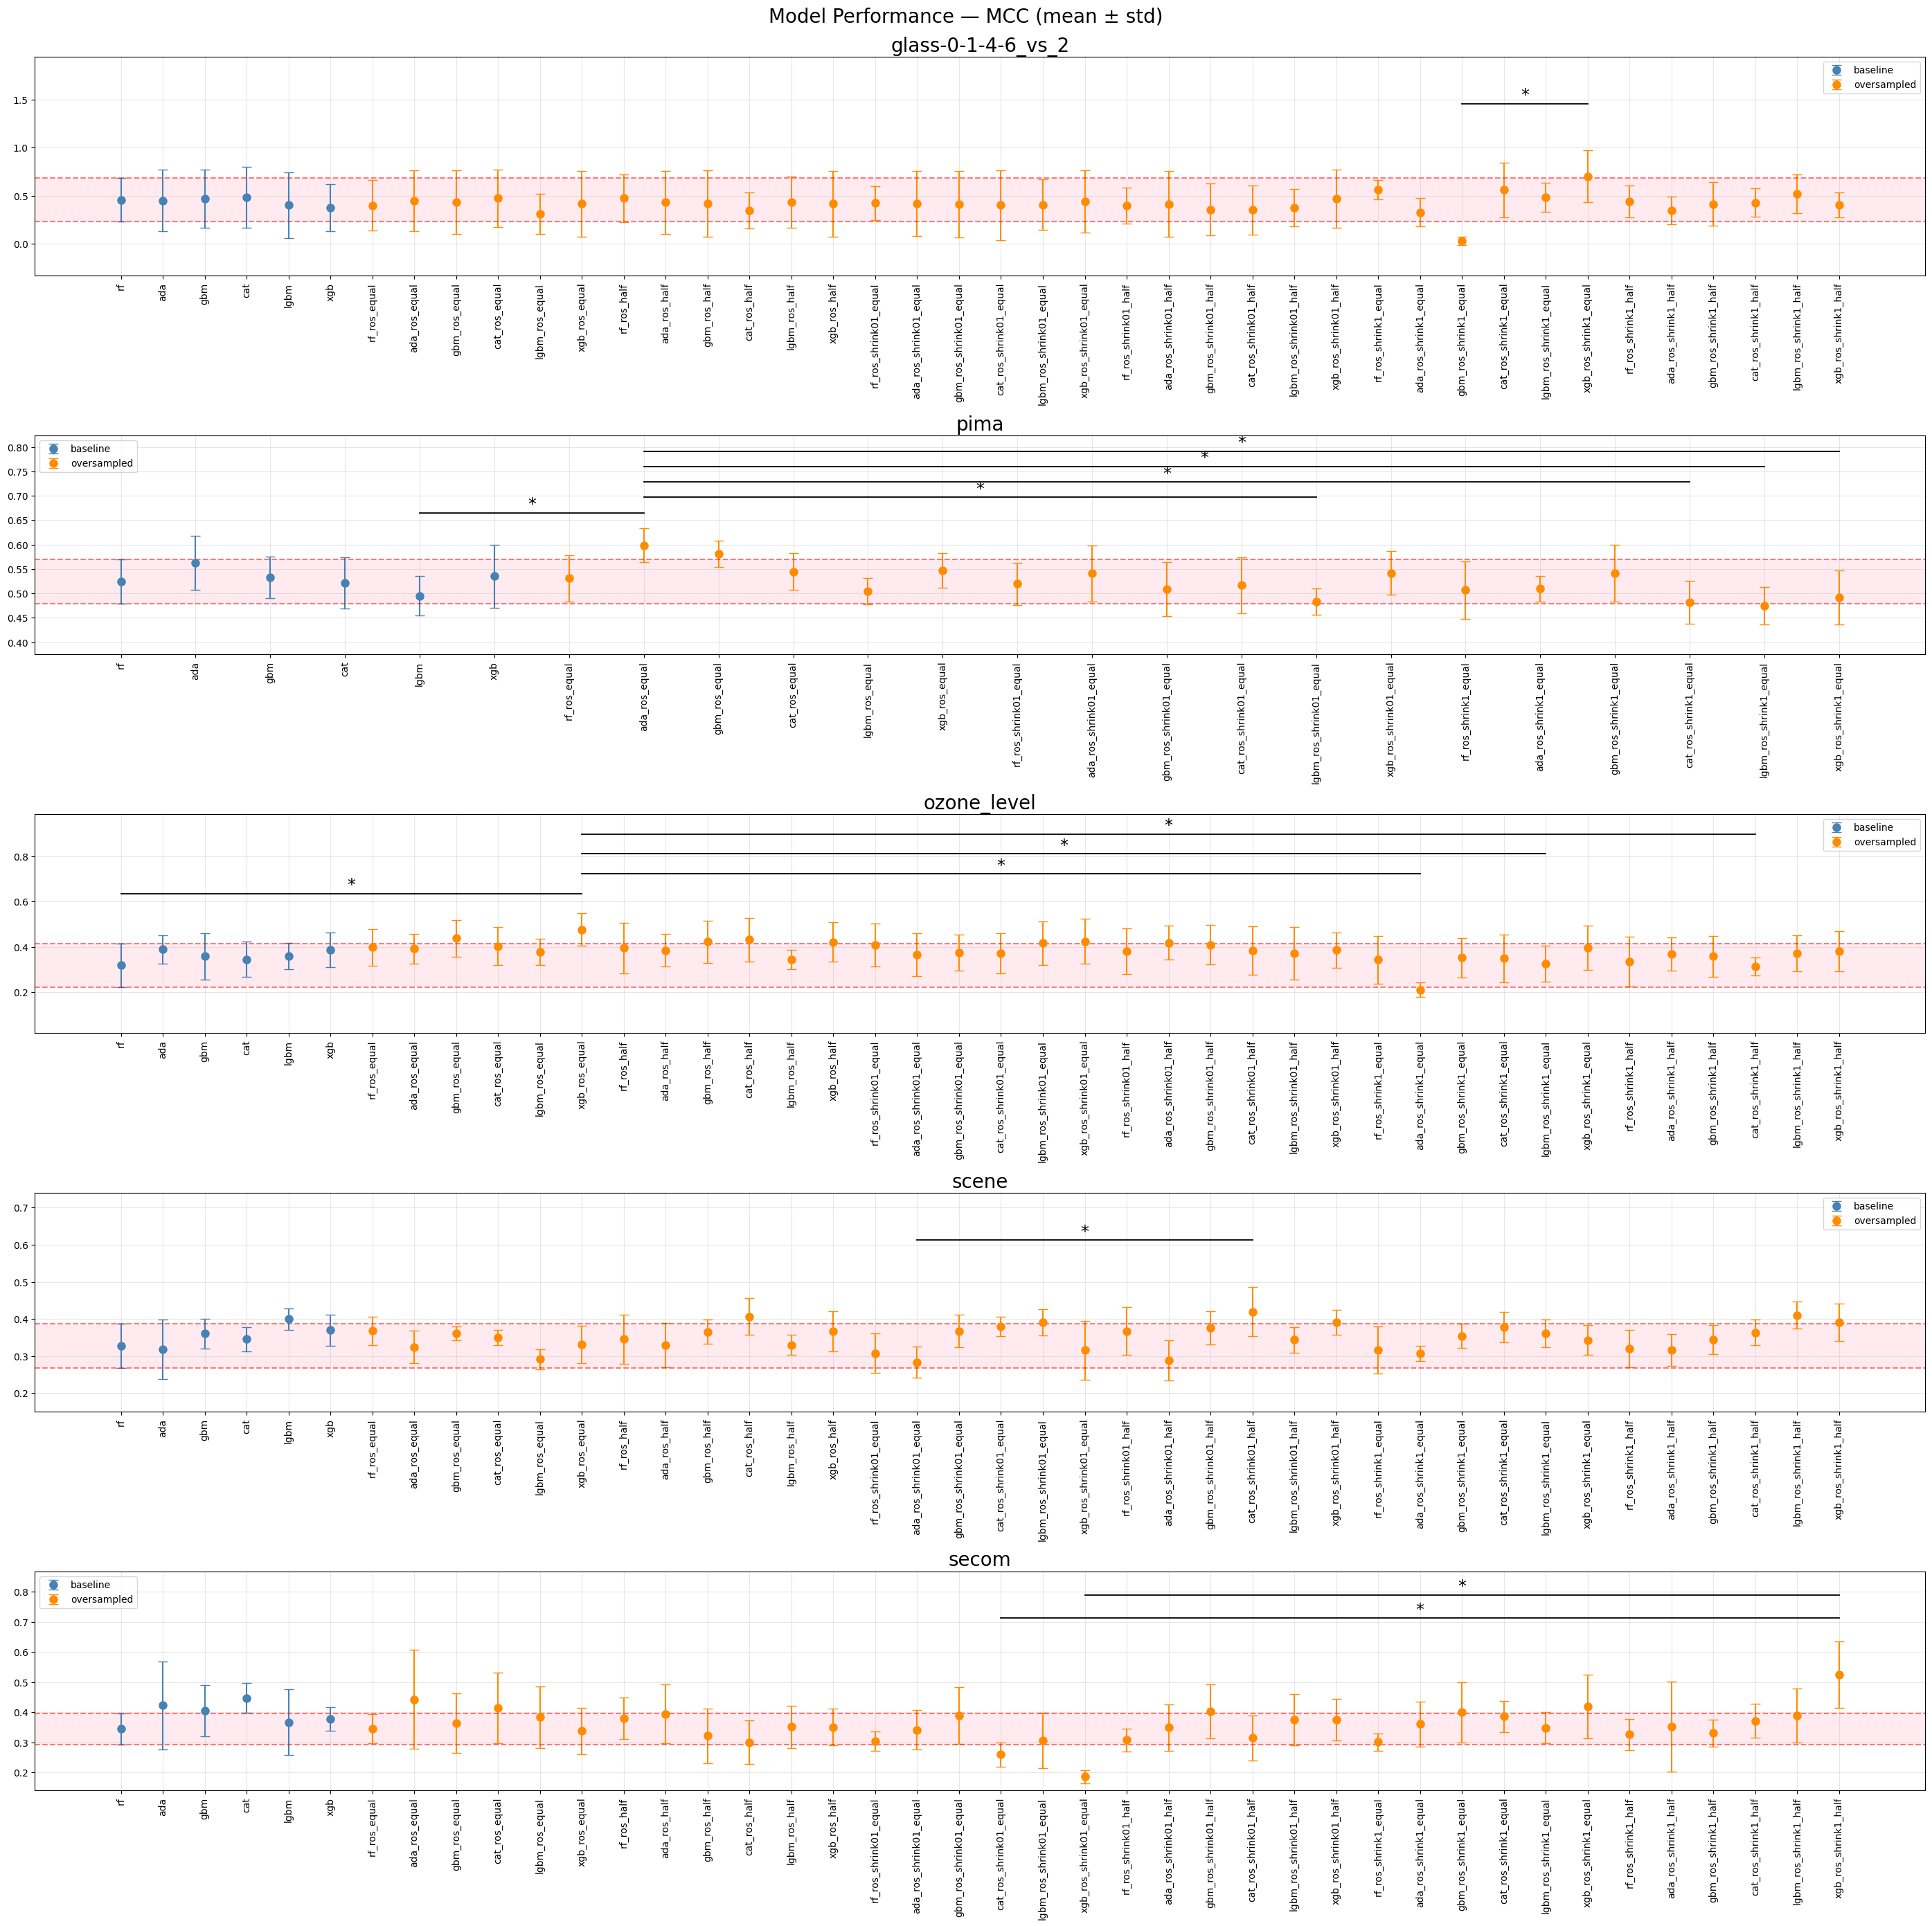

In [17]:
n_datasets = len(datasets)
fig, axes = plt.subplots(nrows=n_datasets, ncols=1, figsize=(28, n_datasets * 5.5))
axes = axes.ravel()

for i, data in enumerate(datasets):
    m = models_for(data)
    df = create_df(scores_dict, data, m)

    ax = axes[i]
    means = df["mcc"]
    stds  = df["mcc_std"]

    upper = df.loc[df.index[0], "mcc"] + df.loc[df.index[0], "mcc_std"]
    lower = df.loc[df.index[0], "mcc"] - df.loc[df.index[0], "mcc_std"]

    base_m = [x for x in m if x in base_models]
    os_m   = [x for x in m if x not in base_models]

    best_model = None
    sig_models = []
    if data in nemenyi_mcc:
        best_model = means.idxmin() if "mcc" == "brier" else means.idxmax()
        posthoc = nemenyi_mcc[data]
        sig_models = [
            x for x in m
            if x != best_model and posthoc.loc[best_model, x] < 0.05
        ]

    ax.errorbar(x=base_m, y=means[base_m], yerr=stds[base_m],
                fmt='o', capsize=5, markersize=8, color='steelblue', label='baseline')
    ax.errorbar(x=os_m, y=means[os_m], yerr=stds[os_m],
                fmt='o', capsize=5, markersize=8, color='darkorange', label='oversampled')

    ylims = compute_ylim(means, stds, upper, lower)
    if sig_models:
        y0, y1 = ylims
        ylims = (y0, y1 + (y1 - y0) * 0.4)
    ax.set_ylim(ylims)

    ax.set_title(data, fontsize=20)
    ax.tick_params(axis='x', rotation=90, labelsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

    ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
    ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)
    ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)

    if sig_models:
        data_max = (means + stds).max()
        add_significance_bars(ax, m, data_max, best_model, sig_models)

plt.tight_layout()
plt.suptitle(f'Model Performance — MCC (mean ± std)', fontsize=20, y=1.01)
plt.savefig('../figures/os_mcc.png', dpi=300, bbox_inches='tight')
plt.show()

### MCC conclusion

The Friedman test is significant in **5 / 5 datasets** and a ROS variant is the best
model in all 5, mirroring the F1 pattern. MCC and F1 tend to agree because both
penalise imbalanced confusion matrices in a similar way. The Nemenyi test finds 1–5
models significantly worse than the best. ROS with shrinkage (`shrink1` and
`shrink01`) is consistently the top cluster.

Again, models with ROS are in general statistically undistinguishable from 
the best performing baseline models, trained without ROS.

## Balanced Accuracy Friedman test

In [18]:
friedman_rows = []
nemenyi_ba = {}

for data in datasets:
    m = models_for(data)
    fold_df = create_fold_df(folds_dict, data, "ba")[m]
    statistic, pvalue = apply_friedman_test(fold_df)
    friedman_rows.append({"dataset": data, "statistic": statistic, "pvalue": pvalue})

    if pvalue < 0.05:
        nemenyi_ba[data] = apply_nemenyi_test(fold_df)

friedman_df = pd.DataFrame(friedman_rows).set_index("dataset")
friedman_df

,statistic,pvalue
dataset,,
glass-0-1-4-6_vs_2,85.452854,5.767770e-05
pima,61.729874,2.139888e-05
ozone_level,100.217570,7.233951e-07
scene,143.723274,2.478787e-13
secom,81.602535,1.666933e-04


## Plot Balanced Accuracy

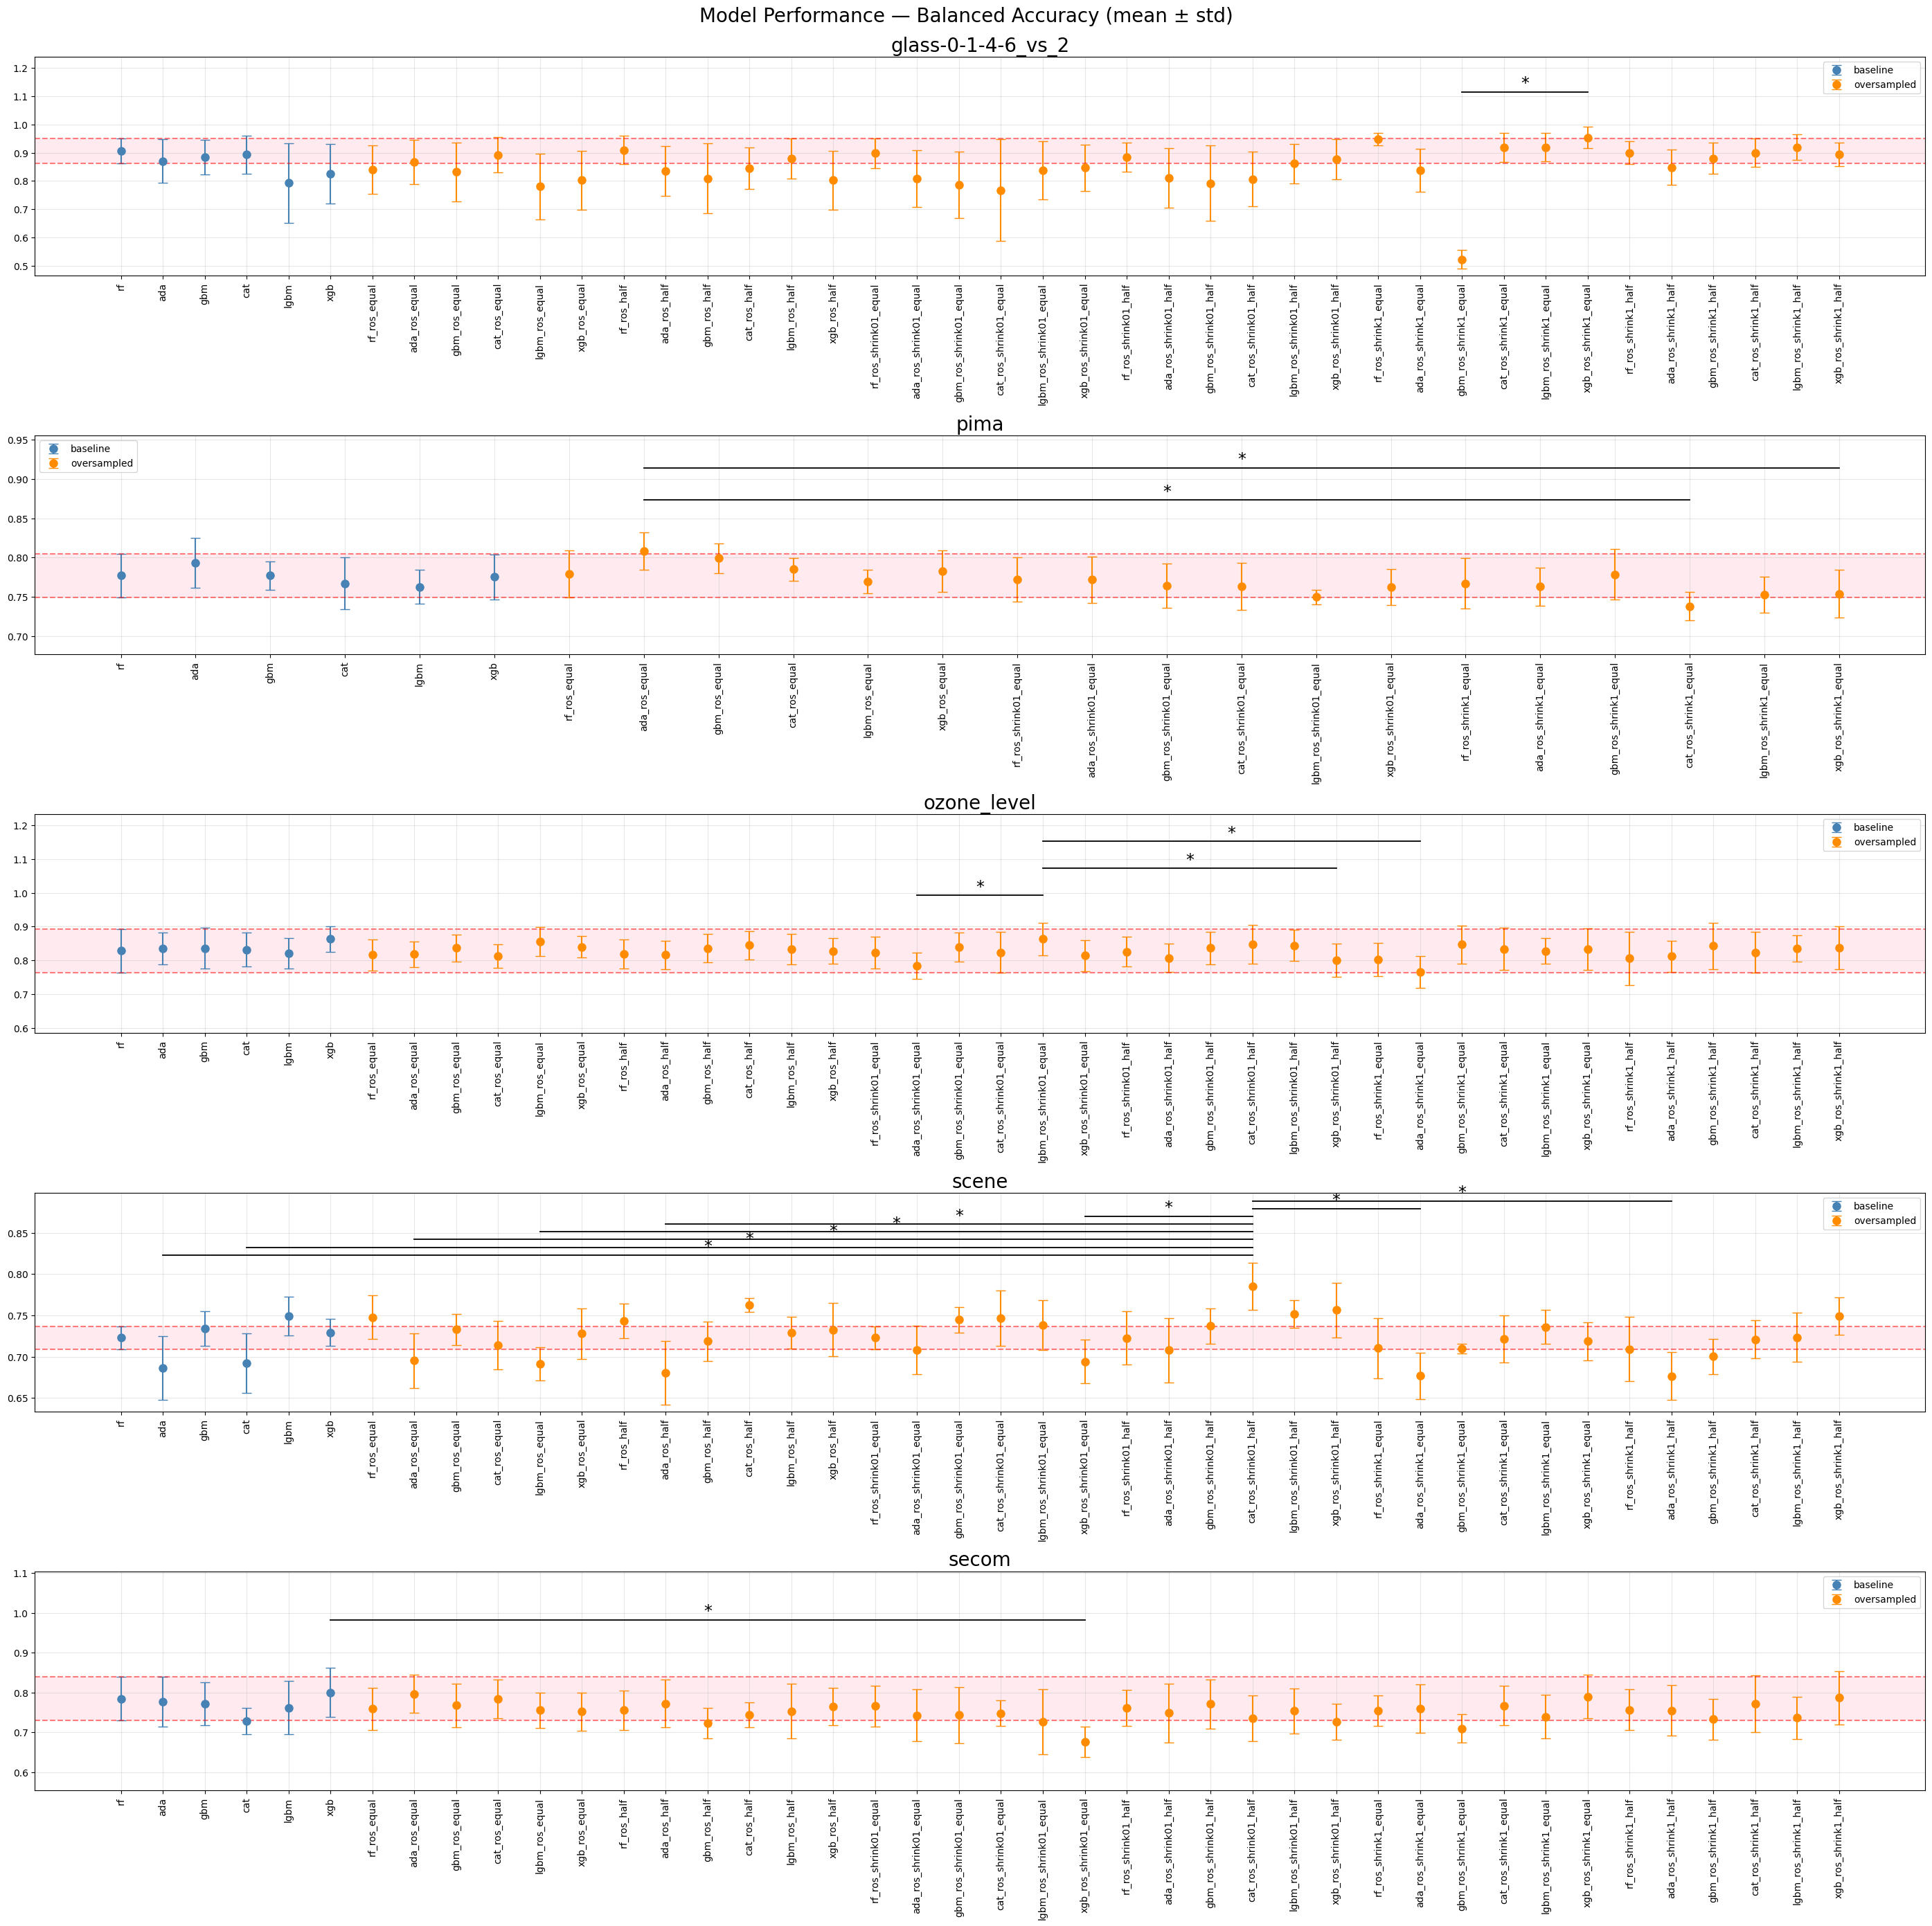

In [19]:
n_datasets = len(datasets)
fig, axes = plt.subplots(nrows=n_datasets, ncols=1, figsize=(28, n_datasets * 5.5))
axes = axes.ravel()

for i, data in enumerate(datasets):
    m = models_for(data)
    df = create_df(scores_dict, data, m)

    ax = axes[i]
    means = df["ba"]
    stds  = df["ba_std"]

    upper = df.loc[df.index[0], "ba"] + df.loc[df.index[0], "ba_std"]
    lower = df.loc[df.index[0], "ba"] - df.loc[df.index[0], "ba_std"]

    base_m = [x for x in m if x in base_models]
    os_m   = [x for x in m if x not in base_models]

    best_model = None
    sig_models = []
    if data in nemenyi_ba:
        best_model = means.idxmin() if "ba" == "brier" else means.idxmax()
        posthoc = nemenyi_ba[data]
        sig_models = [
            x for x in m
            if x != best_model and posthoc.loc[best_model, x] < 0.05
        ]

    ax.errorbar(x=base_m, y=means[base_m], yerr=stds[base_m],
                fmt='o', capsize=5, markersize=8, color='steelblue', label='baseline')
    ax.errorbar(x=os_m, y=means[os_m], yerr=stds[os_m],
                fmt='o', capsize=5, markersize=8, color='darkorange', label='oversampled')

    ylims = compute_ylim(means, stds, upper, lower)
    if sig_models:
        y0, y1 = ylims
        ylims = (y0, y1 + (y1 - y0) * 0.4)
    ax.set_ylim(ylims)

    ax.set_title(data, fontsize=20)
    ax.tick_params(axis='x', rotation=90, labelsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

    ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
    ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)
    ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)

    if sig_models:
        data_max = (means + stds).max()
        add_significance_bars(ax, m, data_max, best_model, sig_models)

plt.tight_layout()
plt.suptitle(f'Model Performance — Balanced Accuracy (mean ± std)', fontsize=20, y=1.01)
plt.savefig('../figures/os_ba.png', dpi=300, bbox_inches='tight')
plt.show()

### Balanced Accuracy conclusion

The Friedman test is significant in **5 / 5 datasets**. A ROS variant is best in 4
out of 5 datasets; the exception is `secom` where the unmodified `xgb` baseline is
ranked first. The Nemenyi test finds 1–8 models significantly worse than the best.
The larger number of significant pairwise differences on `scene` (8 models) suggests
that oversampling has a stronger differentiating effect on balanced accuracy for that
dataset.

## Brier Score Friedman test

In [20]:
friedman_rows = []
nemenyi_brier = {}

for data in datasets:
    m = models_for(data)
    fold_df = create_fold_df(folds_dict, data, "brier")[m]
    statistic, pvalue = apply_friedman_test(fold_df)
    friedman_rows.append({"dataset": data, "statistic": statistic, "pvalue": pvalue})

    if pvalue < 0.05:
        nemenyi_brier[data] = apply_nemenyi_test(fold_df)

friedman_df = pd.DataFrame(friedman_rows).set_index("dataset")
friedman_df

,statistic,pvalue
dataset,,
glass-0-1-4-6_vs_2,172.223920,5.159043e-18
pima,101.968000,6.426779e-12
ozone_level,187.025249,1.538609e-20
scene,186.506977,1.890066e-20
secom,165.685714,6.447858e-17


## Plot Brier Score

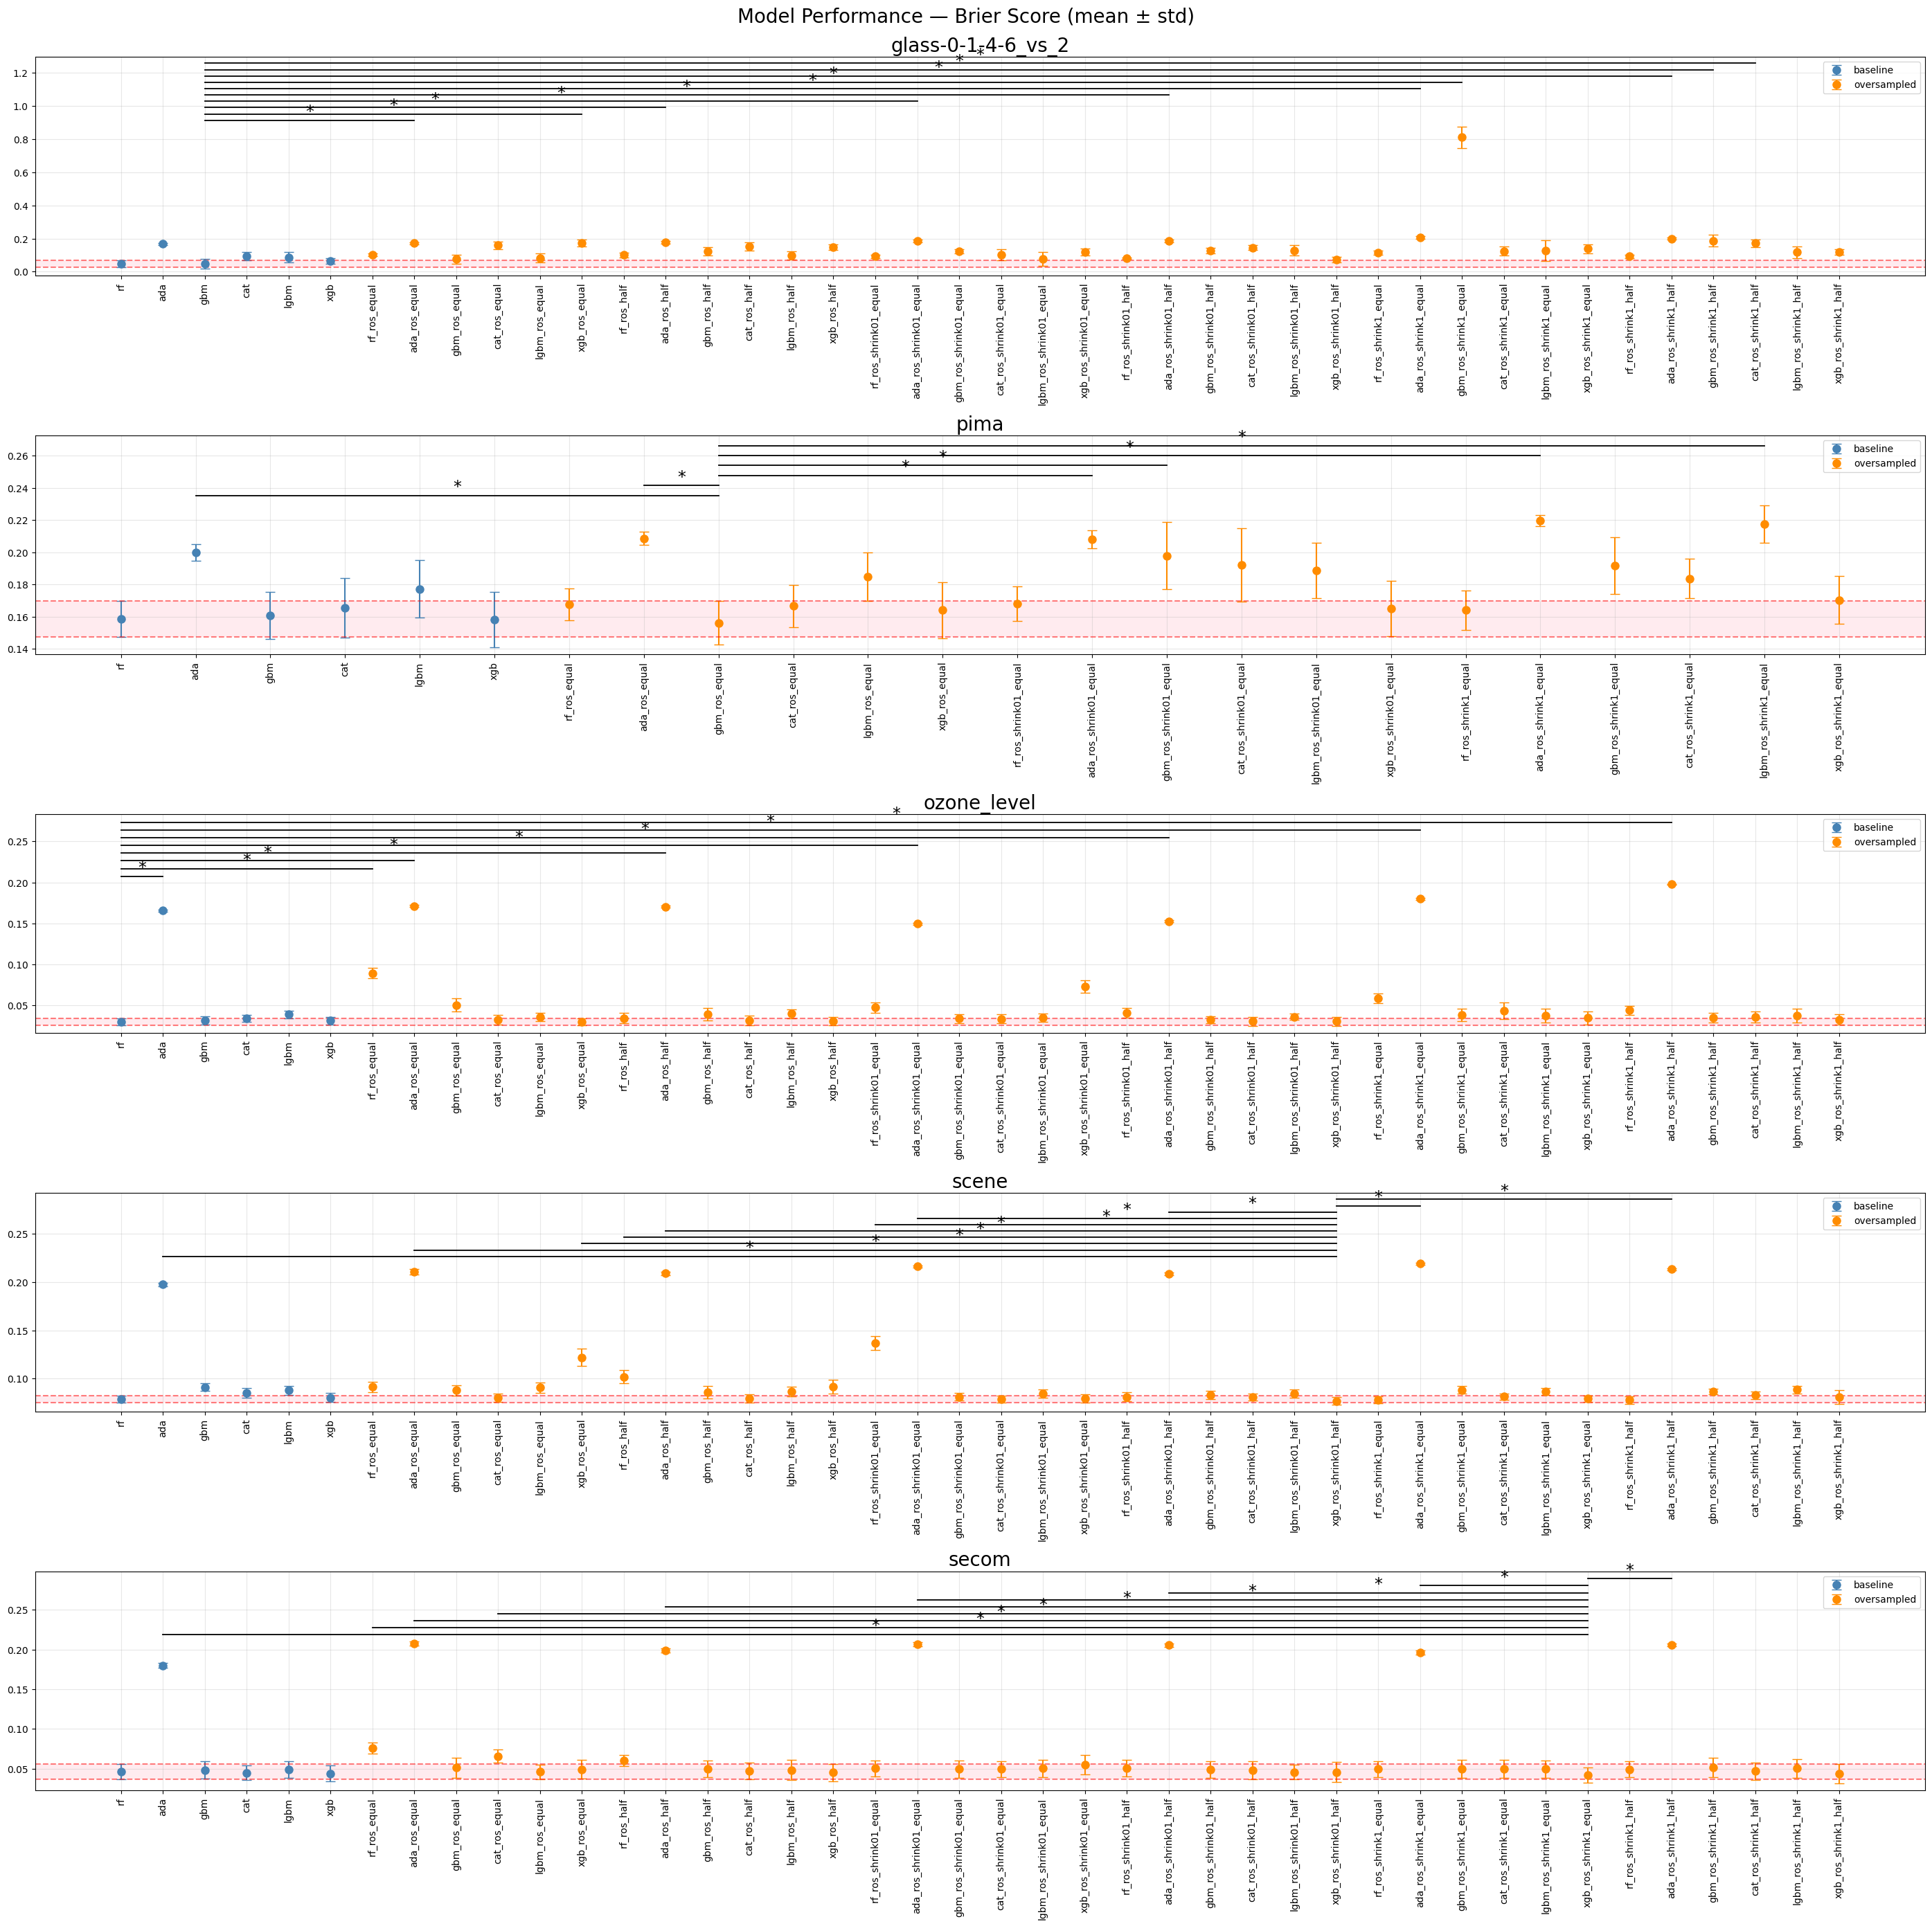

In [21]:
n_datasets = len(datasets)
fig, axes = plt.subplots(nrows=n_datasets, ncols=1, figsize=(28, n_datasets * 5.5))
axes = axes.ravel()

for i, data in enumerate(datasets):
    m = models_for(data)
    df = create_df(scores_dict, data, m)

    ax = axes[i]
    means = df["brier"]
    stds  = df["brier_std"]

    upper = df.loc[df.index[0], "brier"] + df.loc[df.index[0], "brier_std"]
    lower = df.loc[df.index[0], "brier"] - df.loc[df.index[0], "brier_std"]

    base_m = [x for x in m if x in base_models]
    os_m   = [x for x in m if x not in base_models]

    best_model = None
    sig_models = []
    if data in nemenyi_brier:
        best_model = means.idxmin() if "brier" == "brier" else means.idxmax()
        posthoc = nemenyi_brier[data]
        sig_models = [
            x for x in m
            if x != best_model and posthoc.loc[best_model, x] < 0.05
        ]

    ax.errorbar(x=base_m, y=means[base_m], yerr=stds[base_m],
                fmt='o', capsize=5, markersize=8, color='steelblue', label='baseline')
    ax.errorbar(x=os_m, y=means[os_m], yerr=stds[os_m],
                fmt='o', capsize=5, markersize=8, color='darkorange', label='oversampled')

    ylims = compute_ylim(means, stds, upper, lower)
    if sig_models:
        y0, y1 = ylims
        ylims = (y0, y1 + (y1 - y0) * 0.4)
    ax.set_ylim(ylims)

    ax.set_title(data, fontsize=20)
    ax.tick_params(axis='x', rotation=90, labelsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

    ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
    ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)
    ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)

    if sig_models:
        data_max = (means + stds).max()
        add_significance_bars(ax, m, data_max, best_model, sig_models)

plt.tight_layout()
plt.suptitle(f'Model Performance — Brier Score (mean ± std)', fontsize=20, y=1.01)
plt.savefig('../figures/os_brier.png', dpi=300, bbox_inches='tight')
plt.show()

### Brier Score conclusion

The Friedman test is significant in **5 / 5 datasets**. A ROS variant holds the best
Brier score in 3 out of 5 datasets; the unmodified `gbm` or `rf` baseline is best in
the other 2. The Nemenyi test finds the most pairwise significant differences here
(8–10 models per dataset), reflecting that probability calibration is more sensitive
to oversampling strategy than discrimination metrics. Shrinkage variants (`shrink1`,
`shrink01`) tend to be better calibrated than plain ROS, whose duplicated samples can
push predicted probabilities away from empirical frequencies.

## Best ROS variant per model and dataset

In [22]:
best_performance_summary(scores_dict, datasets, metric='roc',  metric_std='roc_std',  factor=3)
best_performance_summary(scores_dict, datasets, metric='ap',   metric_std='ap_std',   factor=3)
best_performance_summary(scores_dict, datasets, metric='ba',   metric_std='ba_std',   factor=3)

,dataset,model,ba,ba_std,best_csl_variant,best_csl_ba,best_csl_ba_std,ba_diff
0,glass-0-1-4-6_vs_2,rf,0.906518,0.044438,rf_ros_shrink1_equal,0.947599,0.022667,0.041081
1,glass-0-1-4-6_vs_2,ada,0.870139,0.077193,ada_ros_equal,0.867361,0.079191,-0.002778
2,glass-0-1-4-6_vs_2,gbm,0.883333,0.061237,gbm_ros_shrink1_half,0.880476,0.055821,-0.002857
3,glass-0-1-4-6_vs_2,cat,0.893056,0.067985,cat_ros_shrink1_equal,0.918542,0.052084,0.025486
4,glass-0-1-4-6_vs_2,lgbm,0.792500,0.140528,lgbm_ros_shrink1_half,0.919633,0.044719,0.127133
5,glass-0-1-4-6_vs_2,xgb,0.825962,0.105199,xgb_ros_shrink1_equal,0.953690,0.038665,0.127728
6,pima,rf,0.777096,0.027878,rf_ros_equal,0.779320,0.030195,0.002224
7,pima,ada,0.793482,0.031753,ada_ros_equal,0.808406,0.023890,0.014923
8,pima,gbm,0.777004,0.018066,gbm_ros_equal,0.799121,0.018710,0.022118
9,pima,cat,0.767114,0.032989,cat_ros_equal,0.785011,0.014736,0.017897


## Join datasets and create table

In [23]:
# Commented out: model list varies per dataset so a flat concat is illustrative only.
# dfs = [create_df(scores_dict, data, models_for(data)) for data in datasets]
# result = pd.concat(dfs, keys=datasets, names=['dataset', 'model'])
# result